# Data Audit & Canonical Split

**Multi-Domain Cross-Attention Fusion with Prototype Memory for Biomedical Image Forgery Localization**
Dataset: Recod.AI / LUC Scientific Image Forgery Detection (Kaggle)

This notebook is the single source of truth for dataset auditing and the train/val/test split.
Every downstream training notebook (baseline, ablation variants, multi-seed runs) should load the
split CSVs saved here instead of recomputing its own split with `glob` — that's what makes ablation
and seed-variance comparisons valid.

## Section 1: Imports and Setup

In [65]:
import os        # interacting with folders/files
import glob      # collecting file paths using patterns like *.png or *.npy
import random     # reproducible random choices during sample inspection
import numpy as np
import pandas as pd

from PIL import Image                    # image reading for png/jpg/jpeg files
from IPython.display import display      # explicit import — safer across kernels than relying on auto-injection

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm  # progress bars for loops over many images
from collections import Counter  # useful for counting extensions/types
from pathlib import Path         # cleaner path handling than manual string joining

# Make tables and plots easier to read
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [66]:
# Kaggle paths
# ================================
# Two things are specific to Kaggle (vs. the earlier Colab/Drive version of
# this notebook) and worth calling out explicitly:
#
# 1. /kaggle/input is READ-ONLY. Any attempt to write there fails silently
#    in some contexts or errors in others, so every output this notebook
#    produces goes under /kaggle/working instead.
# 2. /kaggle/working is exactly what gets preserved when you commit a
#    notebook version, and exactly what you can publish as a new Kaggle
#    Dataset afterwards — which is how the training notebook gets access
#    to the split files produced in Section 7 without re-running any of
#    this audit itself.

DATA_ROOT = Path("/kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection")

TRAIN_AUTHENTIC_DIR = DATA_ROOT / "train_images" / "authentic"
TRAIN_FORGED_DIR    = DATA_ROOT / "train_images" / "forged"
TRAIN_MASKS_DIR      = DATA_ROOT / "train_masks"

SUPP_IMAGES_DIR = DATA_ROOT / "supplemental_images"
SUPP_MASKS_DIR  = DATA_ROOT / "supplemental_masks"

# Some competition mirrors don't ship a supplemental split — check for it
# rather than assuming, so this notebook doesn't crash if it's absent.
HAS_SUPPLEMENTAL = SUPP_IMAGES_DIR.exists() and SUPP_MASKS_DIR.exists()

ANALYSIS_ROOT = Path("/kaggle/working/analysis_outputs")
METADATA_DIR  = ANALYSIS_ROOT / "metadata"
FIGURES_DIR   = ANALYSIS_ROOT / "figures"
SPLITS_DIR    = ANALYSIS_ROOT / "splits"

for d in [METADATA_DIR, FIGURES_DIR, SPLITS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Paths defined and output folders created.")
print(f"Supplemental data found: {HAS_SUPPLEMENTAL}")

Paths defined and output folders created.
Supplemental data found: True


In [67]:
# Print all important paths to confirm correctness

print("DATA_ROOT        :", DATA_ROOT)
print("TRAIN_AUTHENTIC  :", TRAIN_AUTHENTIC_DIR)
print("TRAIN_FORGED     :", TRAIN_FORGED_DIR)
print("TRAIN_MASKS      :", TRAIN_MASKS_DIR)
print("SUPP_IMAGES      :", SUPP_IMAGES_DIR, "(present)" if HAS_SUPPLEMENTAL else "(not found — skipping)")
print("SUPP_MASKS       :", SUPP_MASKS_DIR)
print("ANALYSIS_ROOT    :", ANALYSIS_ROOT)
print("METADATA_DIR     :", METADATA_DIR)
print("FIGURES_DIR      :", FIGURES_DIR)
print("SPLITS_DIR       :", SPLITS_DIR)

DATA_ROOT        : /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection
TRAIN_AUTHENTIC  : /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/authentic
TRAIN_FORGED     : /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_images/forged
TRAIN_MASKS      : /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/train_masks
SUPP_IMAGES      : /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/supplemental_images (present)
SUPP_MASKS       : /kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection/supplemental_masks
ANALYSIS_ROOT    : /kaggle/working/analysis_outputs
METADATA_DIR     : /kaggle/working/analysis_outputs/metadata
FIGURES_DIR      : /kaggle/working/analysis_outputs/figures
SPLITS_DIR       : /kaggle/working/analysis_outputs/splits


In [68]:
# Check if all required folders exist
# ====================================
# This prevents errors later in the notebook.
# Supplemental folders are optional and were already checked above.

required_paths = {
    "TRAIN_AUTHENTIC_DIR": TRAIN_AUTHENTIC_DIR,
    "TRAIN_FORGED_DIR": TRAIN_FORGED_DIR,
    "TRAIN_MASKS_DIR": TRAIN_MASKS_DIR,
}

print("Checking required dataset folders...\n")

all_ok = True
for name, path in required_paths.items():
    exists = path.exists()
    print(f"{name:<25} -> {'FOUND' if exists else 'MISSING'}")
    if not exists:
        all_ok = False

if all_ok:
    print("\nAll required dataset folders are available.")
else:
    print("\nSome required folders are missing. Fix DATA_ROOT before continuing.")

Checking required dataset folders...

TRAIN_AUTHENTIC_DIR       -> FOUND
TRAIN_FORGED_DIR          -> FOUND
TRAIN_MASKS_DIR           -> FOUND

All required dataset folders are available.


In [69]:
# Reproducibility
# ================================
# Ensures consistent results when sampling data, and is the seed the
# canonical split in Section 7 is built from.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


In [70]:
# Plot configuration
# ================================
# Makes visualizations clean and readable

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Plot settings configured.")

Plot settings configured.


## Section 2: Dataset Inventory

First pass over the raw folders: how many files sit in each one, what extensions they use, and whether
the high-level counts look sane before we spend any real compute. This is the cheapest possible sanity
check — a wrong path, an empty folder, or an unexpected file type shows up here in seconds rather than
half an hour into a per-image loop.

In [71]:
# Valid file extensions
# ================================
# We define the image and mask extensions we expect in the dataset.
# This helps us avoid counting unrelated files by mistake.

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}
MASK_EXTENSIONS = {".npy"}

print("Valid image extensions:", IMAGE_EXTENSIONS)
print("Valid mask extensions :", MASK_EXTENSIONS)

Valid image extensions: {'.jpeg', '.jpg', '.png'}
Valid mask extensions : {'.npy'}


In [72]:
# This function scans a folder and returns only files whose extension
# matches the allowed set. The output is sorted for consistency.

def collect_files(folder_path, valid_extensions):
    if not folder_path.exists():
        return []
    files = []
    for file_path in folder_path.iterdir():
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            files.append(file_path)
    return sorted(files)

In [73]:
# We gather files from each folder separately so we can inspect counts
# and later build metadata tables. Sorting happens inside collect_files,
# so these lists are deterministic regardless of filesystem scan order.

train_authentic_files = collect_files(TRAIN_AUTHENTIC_DIR, IMAGE_EXTENSIONS)
train_forged_files = collect_files(TRAIN_FORGED_DIR, IMAGE_EXTENSIONS)
train_mask_files = collect_files(TRAIN_MASKS_DIR, MASK_EXTENSIONS)

supp_image_files = collect_files(SUPP_IMAGES_DIR, IMAGE_EXTENSIONS) if HAS_SUPPLEMENTAL else []
supp_mask_files = collect_files(SUPP_MASKS_DIR, MASK_EXTENSIONS) if HAS_SUPPLEMENTAL else []

print("Files collected successfully.")

Files collected successfully.


In [74]:
# Quick count summary
# ================================
# We print the number of files in each folder to quickly verify that
# the dataset looks complete before moving deeper.

print("train_images/authentic :", len(train_authentic_files))
print("train_images/forged    :", len(train_forged_files))
print("train_masks            :", len(train_mask_files))
print("supplemental_images    :", len(supp_image_files))
print("supplemental_masks     :", len(supp_mask_files))

train_images/authentic : 2377
train_images/forged    : 2751
train_masks            : 2751
supplemental_images    : 48
supplemental_masks     : 48


In [75]:
# This function counts how many files of each extension appear in a list.
# It helps us verify whether the folder contents are consistent.

def count_extensions(file_list):
    return dict(Counter([file_path.suffix.lower() for file_path in file_list]))

In [76]:
# Build dataset inventory table
# ================================
# This table summarizes the contents of each dataset folder.
# It is useful both for inspection now and for saving as metadata later.

inventory_rows = [
    {
        "folder_name": "train_images/authentic",
        "folder_path": str(TRAIN_AUTHENTIC_DIR),
        "file_count": len(train_authentic_files),
        "extensions": count_extensions(train_authentic_files),
        "expected_type": "image"
    },
    {
        "folder_name": "train_images/forged",
        "folder_path": str(TRAIN_FORGED_DIR),
        "file_count": len(train_forged_files),
        "extensions": count_extensions(train_forged_files),
        "expected_type": "image"
    },
    {
        "folder_name": "train_masks",
        "folder_path": str(TRAIN_MASKS_DIR),
        "file_count": len(train_mask_files),
        "extensions": count_extensions(train_mask_files),
        "expected_type": "mask"
    },
    {
        "folder_name": "supplemental_images",
        "folder_path": str(SUPP_IMAGES_DIR),
        "file_count": len(supp_image_files),
        "extensions": count_extensions(supp_image_files),
        "expected_type": "image"
    },
    {
        "folder_name": "supplemental_masks",
        "folder_path": str(SUPP_MASKS_DIR),
        "file_count": len(supp_mask_files),
        "extensions": count_extensions(supp_mask_files),
        "expected_type": "mask"
    },
]

inventory_df = pd.DataFrame(inventory_rows)
inventory_df

,folder_name,folder_path,file_count,extensions,expected_type
0,train_images/authentic,/kaggle/input/competitions/recodai-luc-scienti...,2377,{'.png': 2377},image
1,train_images/forged,/kaggle/input/competitions/recodai-luc-scienti...,2751,{'.png': 2751},image
2,train_masks,/kaggle/input/competitions/recodai-luc-scienti...,2751,{'.npy': 2751},mask
3,supplemental_images,/kaggle/input/competitions/recodai-luc-scienti...,48,{'.png': 48},image
4,supplemental_masks,/kaggle/input/competitions/recodai-luc-scienti...,48,{'.npy': 48},mask


In [77]:
# Basic consistency checks
# ================================
# These checks do not yet validate pair-by-pair matching.
# They only compare overall counts to flag obvious problems early.

print("Basic consistency checks:\n")

print(f"Forged images vs train masks       : {len(train_forged_files)} vs {len(train_mask_files)}")
print(f"Supplemental images vs supp masks  : {len(supp_image_files)} vs {len(supp_mask_files)}")

if len(supp_image_files) == len(supp_mask_files):
    print("Supplemental image/mask counts look consistent.")
else:
    print("Supplemental image/mask counts do NOT match. Needs investigation.")

if len(train_forged_files) == len(train_mask_files):
    print("Forged image/train mask counts look consistent.")
else:
    print("Forged image/train mask counts do NOT match. Needs investigation.")

Basic consistency checks:

Forged images vs train masks       : 2751 vs 2751
Supplemental images vs supp masks  : 48 vs 48
Supplemental image/mask counts look consistent.
Forged image/train mask counts look consistent.


In [78]:
# Looking at a few filenames helps us understand the naming convention.
# This will be important in Section 3 when we match images to masks.

def preview_filenames(file_list, n=5):
    return [file_path.name for file_path in file_list[:n]]

preview_table = pd.DataFrame({
    "train_authentic_sample_names": pd.Series(preview_filenames(train_authentic_files)),
    "train_forged_sample_names": pd.Series(preview_filenames(train_forged_files)),
    "train_mask_sample_names": pd.Series(preview_filenames(train_mask_files)),
    "supp_image_sample_names": pd.Series(preview_filenames(supp_image_files)),
    "supp_mask_sample_names": pd.Series(preview_filenames(supp_mask_files)),
})

preview_table

,train_authentic_sample_names,train_forged_sample_names,train_mask_sample_names,supp_image_sample_names,supp_mask_sample_names
0,10.png,10.png,10.npy,13977.png,13977.npy
1,10015.png,10015.png,10015.npy,14128.png,14128.npy
2,10017.png,10017.png,10017.npy,15257.png,15257.npy
3,10030.png,10030.png,10030.npy,16338.png,16338.npy
4,10070.png,10070.png,10070.npy,16714.png,16714.npy


In [79]:
# We save this table so the training notebook (or any later section) does
# not need to rebuild the basic folder summary from scratch.

inventory_save_path = METADATA_DIR / "dataset_inventory.csv"
inventory_df.to_csv(inventory_save_path, index=False)

print(f"Dataset inventory saved to: {inventory_save_path}")

Dataset inventory saved to: /kaggle/working/analysis_outputs/metadata/dataset_inventory.csv


## Section 3: Image-Mask Pairing Validation

Every forged image needs exactly one mask, matched by filename stem. We build that pairing explicitly
here and flag anything that doesn't line up — an orphan mask with no image, an image with no mask —
because a segmentation model trained on a silently mismatched pair doesn't error out, it just learns
garbage, and that failure mode is far harder to debug later than catching it now.

In [80]:
# The "stem" is the filename without extension.
# Example:
#   image_001.png -> image_001
#   image_001.npy -> image_001
#
# We use stems because image and mask files may live in different folders
# but should share the same base name if they are a correct pair.

def build_stem_index(file_list):
    return {file_path.stem: file_path for file_path in file_list}

In [81]:
# These dictionaries let us quickly check whether an image has a matching mask
# with exactly the same filename stem.

forged_image_index = build_stem_index(train_forged_files)
train_mask_index = build_stem_index(train_mask_files)

supp_image_index = build_stem_index(supp_image_files)
supp_mask_index = build_stem_index(supp_mask_files)

print("Stem indices created successfully.")

Stem indices created successfully.


In [82]:
# Validate forged image == train mask pairs
# ================================
# For each forged image, we check whether a mask with the same stem exists.
# We also record the pairing status so that all results are stored cleanly.

forged_pair_rows = []

for stem, image_path in forged_image_index.items():
    if stem in train_mask_index:
        mask_path = train_mask_index[stem]
        pair_status = "matched"
    else:
        mask_path = None
        pair_status = "missing_mask"

    forged_pair_rows.append({
        "sample_source": "train",
        "sample_type": "forged",
        "sample_id": stem,
        "image_path": str(image_path),
        "mask_path": str(mask_path) if mask_path is not None else None,
        "pair_status": pair_status
    })

forged_pairs_df = pd.DataFrame(forged_pair_rows)
forged_pairs_df.head()

,sample_source,sample_type,sample_id,image_path,mask_path,pair_status
0,train,forged,10,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
1,train,forged,10015,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
2,train,forged,10017,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
3,train,forged,10030,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
4,train,forged,10070,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched


In [83]:
# Validate supplemental image == supplemental mask pairs
# ================================
# We repeat the same process for the supplemental set, if it exists.

supp_pair_columns = ["sample_source", "sample_type", "sample_id", "image_path", "mask_path", "pair_status"]

if HAS_SUPPLEMENTAL:
    supp_pair_rows = []
    for stem, image_path in supp_image_index.items():
        if stem in supp_mask_index:
            mask_path = supp_mask_index[stem]
            pair_status = "matched"
        else:
            mask_path = None
            pair_status = "missing_mask"

        supp_pair_rows.append({
            "sample_source": "supplemental",
            "sample_type": "forged",
            "sample_id": stem,
            "image_path": str(image_path),
            "mask_path": str(mask_path) if mask_path is not None else None,
            "pair_status": pair_status
        })
    supp_pairs_df = pd.DataFrame(supp_pair_rows)
else:
    supp_pairs_df = pd.DataFrame(columns=supp_pair_columns)

supp_pairs_df.head()

,sample_source,sample_type,sample_id,image_path,mask_path,pair_status
0,supplemental,forged,13977,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
1,supplemental,forged,14128,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
2,supplemental,forged,15257,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
3,supplemental,forged,16338,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
4,supplemental,forged,16714,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched


In [84]:
# Check for orphan masks
# ================================
# An orphan mask is a mask file that does not have a matching image.
# These can silently create confusion, so we detect them explicitly.

forged_orphan_mask_stems = sorted(set(train_mask_index.keys()) - set(forged_image_index.keys()))
supp_orphan_mask_stems = sorted(set(supp_mask_index.keys()) - set(supp_image_index.keys()))

print("Orphan train masks       :", len(forged_orphan_mask_stems))
print("Orphan supplemental masks:", len(supp_orphan_mask_stems))

Orphan train masks       : 0
Orphan supplemental masks: 0


In [85]:
# Pairing summary
# ================================
# This gives a compact overview of whether matching succeeded.

print("Forged pair status summary:")
print(forged_pairs_df["pair_status"].value_counts(dropna=False))
print()

print("Supplemental pair status summary:")
if len(supp_pairs_df) > 0:
    print(supp_pairs_df["pair_status"].value_counts(dropna=False))
else:
    print("(no supplemental data found)")

Forged pair status summary:
pair_status
matched    2751
Name: count, dtype: int64

Supplemental pair status summary:
pair_status
matched    48
Name: count, dtype: int64


In [86]:
# Unified paired table
# ================================
# We combine train-forged pairs and supplemental pairs into one table.
# This will be very useful in later sections such as:
# - size checking
# - mask content analysis
# - the canonical split in Section 7

paired_forgery_df = pd.concat([forged_pairs_df, supp_pairs_df], ignore_index=True)
paired_forgery_df = paired_forgery_df.sort_values(by=["sample_source", "sample_id"]).reset_index(drop=True)

paired_forgery_df.head()

,sample_source,sample_type,sample_id,image_path,mask_path,pair_status
0,supplemental,forged,13977,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
1,supplemental,forged,14128,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
2,supplemental,forged,15257,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
3,supplemental,forged,16338,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched
4,supplemental,forged,16714,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,matched


In [87]:
# Authentic metadata table
# ================================
# Authentic images do not have masks. They are not used for segmentation
# training in this pipeline, but we keep them in a metadata table for
# completeness and for the visual-inspection section below.

auth_rows = []

for image_path in train_authentic_files:
    auth_rows.append({
        "sample_source": "train",
        "sample_type": "authentic",
        "sample_id": image_path.stem,
        "image_path": str(image_path),
        "mask_path": None,
        "pair_status": "no_mask_expected"
    })

authentic_df = pd.DataFrame(auth_rows)
authentic_df = authentic_df.sort_values(by="sample_id").reset_index(drop=True)

authentic_df.head()

,sample_source,sample_type,sample_id,image_path,mask_path,pair_status
0,train,authentic,10,/kaggle/input/competitions/recodai-luc-scienti...,None,no_mask_expected
1,train,authentic,10015,/kaggle/input/competitions/recodai-luc-scienti...,None,no_mask_expected
2,train,authentic,10017,/kaggle/input/competitions/recodai-luc-scienti...,None,no_mask_expected
3,train,authentic,10030,/kaggle/input/competitions/recodai-luc-scienti...,None,no_mask_expected
4,train,authentic,10070,/kaggle/input/competitions/recodai-luc-scienti...,None,no_mask_expected


In [88]:
# Full metadata base table
# ================================
# This table includes:
# - forged train samples
# - supplemental forged samples
# - authentic train samples
#
# It will become the main metadata foundation for later sections.

metadata_base_df = pd.concat([paired_forgery_df, authentic_df], ignore_index=True)
metadata_base_df = metadata_base_df.sort_values(by=["sample_type", "sample_source", "sample_id"]).reset_index(drop=True)

metadata_base_df.head()

,sample_source,sample_type,sample_id,image_path,mask_path,pair_status
0,train,authentic,10,/kaggle/input/competitions/recodai-luc-scienti...,None,no_mask_expected
1,train,authentic,10015,/kaggle/input/competitions/recodai-luc-scienti...,None,no_mask_expected
2,train,authentic,10017,/kaggle/input/competitions/recodai-luc-scienti...,None,no_mask_expected
3,train,authentic,10030,/kaggle/input/competitions/recodai-luc-scienti...,None,no_mask_expected
4,train,authentic,10070,/kaggle/input/competitions/recodai-luc-scienti...,None,no_mask_expected


In [89]:
# Save pairing metadata
# ================================
# We save both the forgery pairing table and the full metadata base table
# so later sections and the training notebook can reuse them directly.

paired_forgery_save_path = METADATA_DIR / "paired_forgery_table.csv"
metadata_base_save_path = METADATA_DIR / "metadata_base_table.csv"

paired_forgery_df.to_csv(paired_forgery_save_path, index=False)
metadata_base_df.to_csv(metadata_base_save_path, index=False)

print(f"Saved paired forgery table to: {paired_forgery_save_path}")
print(f"Saved full metadata base table to: {metadata_base_save_path}")

Saved paired forgery table to: /kaggle/working/analysis_outputs/metadata/paired_forgery_table.csv
Saved full metadata base table to: /kaggle/working/analysis_outputs/metadata/metadata_base_table.csv


## Section 4: Image and Mask Size Audit

The paper states raw images range from 64 to 4,417 pixels before everything is resized to 256x256 for
training — this section is where that number comes from. We measure every image and mask, confirm
image/mask shapes agree with each other before any resizing happens, and inspect the extremes so we
know exactly what preprocessing has to be robust to, rather than guessing.

In [90]:
# These functions return height and width without doing any preprocessing.
# We use them to audit the raw dataset geometry as it exists on disk.
#
# load_binary_mask() is the ONE canonical decoder for turning a raw .npy mask
# into a clean (H, W) binary array. Some masks in this dataset carry a small
# leading/trailing channel axis (e.g. shape (2, H, W)) rather than plain
# (H, W) — naively taking mask.shape[:2] on those grabs (channel, H) instead
# of (H, W), silently corrupting every size statistic downstream. Every
# section that needs a mask's real shape or content (this one, Section 5,
# Section 6) calls this same function, so there is exactly one place to get
# the channel-handling right instead of three separate copies that can
# quietly drift apart from each other.

def load_binary_mask(mask_path):
    """
    Converts a stored mask into a proper 2D binary forgery mask.

    Supported patterns:
    - (H, W)
    - (1, H, W) or (H, W, 1)
    - (C, H, W) or (H, W, C)

    General rule for multi-channel masks:
    - identify the channel axis as the smallest axis
    - treat channel 0 as background
    - any positive value in channels 1..end marks a forged pixel
    """
    mask = np.load(mask_path)

    if mask.ndim == 2:
        binary_mask = (mask > 0).astype(np.uint8)

    elif mask.ndim == 3:
        shape = mask.shape
        channel_axis = int(np.argmin(shape))
        mask_reordered = np.moveaxis(mask, channel_axis, 0)

        if mask_reordered.shape[0] == 1:
            binary_mask = (mask_reordered[0] > 0).astype(np.uint8)
        else:
            binary_mask = (np.any(mask_reordered[1:] > 0, axis=0)).astype(np.uint8)

    else:
        raise ValueError(f"Unexpected mask ndim={mask.ndim}, shape={mask.shape} for {mask_path}")

    if binary_mask.ndim != 2:
        raise ValueError(f"Mask could not be converted to 2D. Got shape {binary_mask.shape} for {mask_path}")

    return binary_mask


def get_image_shape(image_path):
    with Image.open(image_path) as img:
        width, height = img.size
    return height, width

def get_mask_shape(mask_path):
    binary_mask = load_binary_mask(mask_path)
    return binary_mask.shape

In [91]:
# Size audit for paired forgery samples
# ================================
# For each forged/supplemental image-mask pair, we record:
# - image height and width
# - mask height and width
# - image aspect ratio
# - whether image and mask shapes match exactly

paired_size_rows = []

for _, row in tqdm(paired_forgery_df.iterrows(), total=len(paired_forgery_df)):
    image_path = Path(row["image_path"])
    mask_path = Path(row["mask_path"])

    img_h, img_w = get_image_shape(image_path)
    mask_h, mask_w = get_mask_shape(mask_path)

    paired_size_rows.append({
        "sample_source": row["sample_source"],
        "sample_type": row["sample_type"],
        "sample_id": row["sample_id"],
        "image_path": row["image_path"],
        "mask_path": row["mask_path"],
        "image_height": img_h,
        "image_width": img_w,
        "mask_height": mask_h,
        "mask_width": mask_w,
        "image_aspect_ratio": img_w / img_h,
        "mask_aspect_ratio": mask_w / mask_h,
        "shapes_match": (img_h == mask_h) and (img_w == mask_w)
    })

paired_size_df = pd.DataFrame(paired_size_rows)
paired_size_df.head()

  0%|          | 0/2799 [00:00<?, ?it/s]

,sample_source,sample_type,sample_id,image_path,mask_path,image_height,image_width,mask_height,mask_width,image_aspect_ratio,mask_aspect_ratio,shapes_match
0,supplemental,forged,13977,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,1382,1359,1382,1359,0.983357,0.983357,True
1,supplemental,forged,14128,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,497,988,497,988,1.987928,1.987928,True
2,supplemental,forged,15257,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,2790,1702,2790,1702,0.610036,0.610036,True
3,supplemental,forged,16338,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,4417,2080,4417,2080,0.470908,0.470908,True
4,supplemental,forged,16714,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,1205,2051,1205,2051,1.702075,1.702075,True


In [92]:
# Size audit for authentic images
# ================================
# Authentic images do not have masks, but we still record height, width,
# and aspect ratio for completeness.

auth_size_rows = []

for _, row in tqdm(authentic_df.iterrows(), total=len(authentic_df)):
    image_path = Path(row["image_path"])
    img_h, img_w = get_image_shape(image_path)

    auth_size_rows.append({
        "sample_source": row["sample_source"],
        "sample_type": row["sample_type"],
        "sample_id": row["sample_id"],
        "image_path": row["image_path"],
        "mask_path": None,
        "image_height": img_h,
        "image_width": img_w,
        "mask_height": None,
        "mask_width": None,
        "image_aspect_ratio": img_w / img_h
    })

auth_size_df = pd.DataFrame(auth_size_rows)
auth_size_df.head()

  0%|          | 0/2377 [00:00<?, ?it/s]

,sample_source,sample_type,sample_id,image_path,mask_path,image_height,image_width,mask_height,mask_width,image_aspect_ratio
0,train,authentic,10,/kaggle/input/competitions/recodai-luc-scienti...,None,512,648,None,None,1.265625
1,train,authentic,10015,/kaggle/input/competitions/recodai-luc-scienti...,None,1200,1600,None,None,1.333333
2,train,authentic,10017,/kaggle/input/competitions/recodai-luc-scienti...,None,256,320,None,None,1.250000
3,train,authentic,10030,/kaggle/input/competitions/recodai-luc-scienti...,None,666,1000,None,None,1.501502
4,train,authentic,10070,/kaggle/input/competitions/recodai-luc-scienti...,None,712,414,None,None,0.581461


In [93]:
# Shape alignment summary
# ================================
# This tells us whether image and mask dimensions match exactly.
# For segmentation, mismatched shapes would be a serious problem.

print("Shape match summary for forged + supplemental pairs:\n")
print(paired_size_df["shapes_match"].value_counts(dropna=False))

Shape match summary for forged + supplemental pairs:

shapes_match
True    2799
Name: count, dtype: int64


In [94]:
# Inspect mismatched pairs (if any)
# ================================
# If there are shape mismatches, we display them here for debugging.

mismatched_shapes_df = paired_size_df[paired_size_df["shapes_match"] == False].copy()
mismatched_shapes_df

,sample_source,sample_type,sample_id,image_path,mask_path,image_height,image_width,mask_height,mask_width,image_aspect_ratio,mask_aspect_ratio,shapes_match


In [95]:
# Summary statistics: all image sizes
# ================================
# We combine paired and authentic image size data to understand the full dataset.

all_image_sizes_df = pd.concat([
    paired_size_df[["sample_source", "sample_type", "sample_id", "image_height", "image_width", "image_aspect_ratio"]],
    auth_size_df[["sample_source", "sample_type", "sample_id", "image_height", "image_width", "image_aspect_ratio"]]
], ignore_index=True)

all_image_sizes_df[["image_height", "image_width", "image_aspect_ratio"]].describe()

,image_height,image_width,image_aspect_ratio
count,5176.000000,5176.000000,5176.000000
mean,701.301391,939.034003,1.943924
std,690.449825,736.724698,2.073047
min,64.000000,74.000000,0.123876
25%,256.000000,410.750000,1.000000
50%,512.000000,696.000000,1.333333
75%,763.000000,1067.250000,1.501502
max,4417.000000,4000.000000,18.625000


In [96]:
# Summary statistics: mask sizes
# ================================
# This applies only to paired forgery samples because authentic images have no masks.

paired_size_df[["mask_height", "mask_width", "mask_aspect_ratio"]].describe()

,mask_height,mask_width,mask_aspect_ratio
count,2799.000000,2799.000000,2799.000000
mean,704.083959,944.500536,1.961397
std,687.805660,731.947720,2.094046
min,64.000000,74.000000,0.123876
25%,256.000000,427.000000,1.000000
50%,512.000000,696.000000,1.333333
75%,902.500000,1137.500000,1.501502
max,4417.000000,4000.000000,18.625000


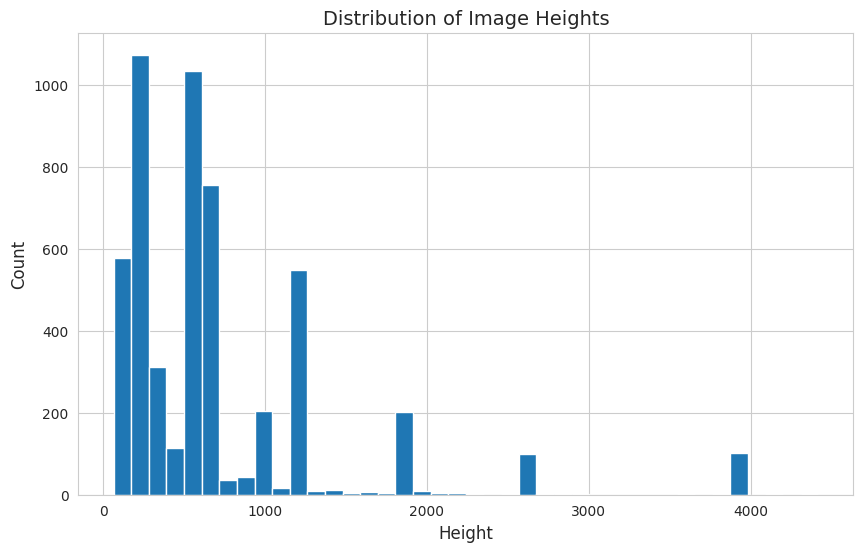

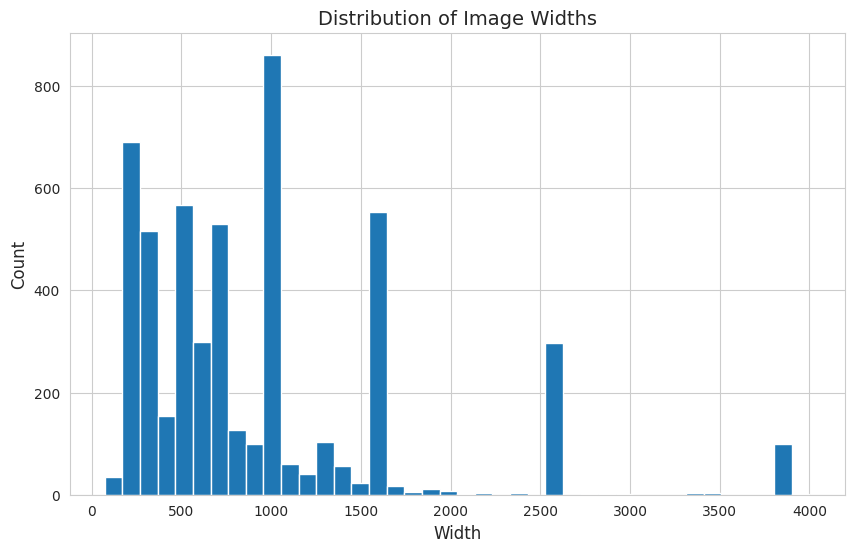

In [97]:
# Histograms: image height and width
# ================================
# These plots help us understand how wide the size variation is across the dataset.

plt.figure()
plt.hist(all_image_sizes_df["image_height"], bins=40)
plt.title("Distribution of Image Heights")
plt.xlabel("Height")
plt.ylabel("Count")
plt.savefig(FIGURES_DIR / "image_height_hist.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
plt.hist(all_image_sizes_df["image_width"], bins=40)
plt.title("Distribution of Image Widths")
plt.xlabel("Width")
plt.ylabel("Count")
plt.savefig(FIGURES_DIR / "image_width_hist.png", dpi=150, bbox_inches="tight")
plt.show()

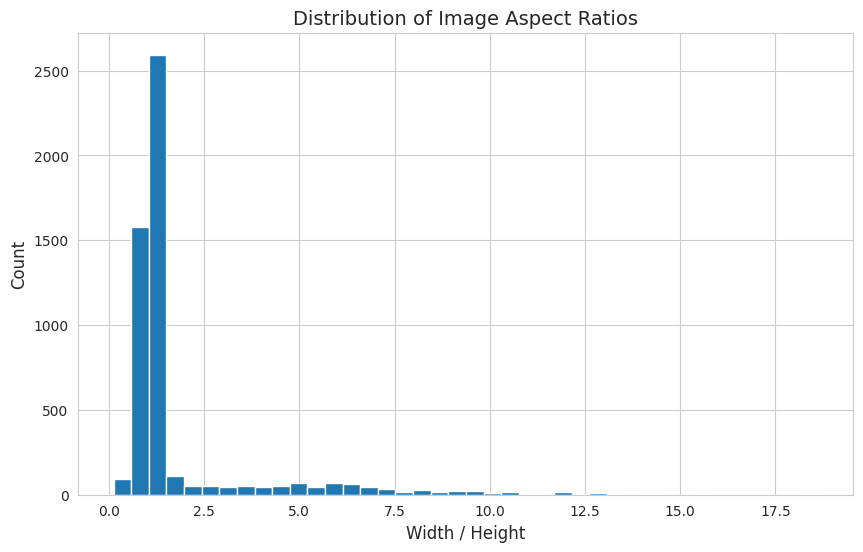

In [98]:
# Histogram: image aspect ratios
# ================================
# Aspect ratio variation is important because direct square resizing
# can distort images if the ratios vary a lot.

plt.figure()
plt.hist(all_image_sizes_df["image_aspect_ratio"], bins=40)
plt.title("Distribution of Image Aspect Ratios")
plt.xlabel("Width / Height")
plt.ylabel("Count")
plt.savefig(FIGURES_DIR / "aspect_ratio_hist.png", dpi=150, bbox_inches="tight")
plt.show()

In [99]:
# Extreme examples by image size
# ================================
# We inspect the smallest and largest images to understand the range
# of cases that preprocessing must handle.

smallest_images_df = all_image_sizes_df.sort_values(by=["image_height", "image_width"]).head(10)
largest_images_df = all_image_sizes_df.sort_values(by=["image_height", "image_width"], ascending=False).head(10)

print("Smallest images:")
display(smallest_images_df)

print("Largest images:")
display(largest_images_df)

Smallest images:


,sample_source,sample_type,sample_id,image_height,image_width,image_aspect_ratio
68,train,forged,10408,64,434,6.781250
2330,train,forged,58252,64,434,6.781250
2818,train,authentic,10408,64,434,6.781250
4768,train,authentic,58252,64,434,6.781250
1648,train,forged,43285,64,814,12.718750
4190,train,authentic,43285,64,814,12.718750
821,train,forged,26121,64,1192,18.625000
3475,train,authentic,26121,64,1192,18.625000
1580,train,forged,41852,65,391,6.015385
4130,train,authentic,41852,65,391,6.015385


Largest images:


,sample_source,sample_type,sample_id,image_height,image_width,image_aspect_ratio
3,supplemental,forged,16338,4417,2080,0.470908
44,supplemental,forged,60087,4159,2781,0.668670
43,supplemental,forged,59764,4149,3326,0.801639
38,supplemental,forged,49484,3919,2994,0.763970
54,train,forged,10138,3888,2592,0.666667
85,train,forged,10799,3888,2592,0.666667
165,train,forged,12289,3888,2592,0.666667
182,train,forged,12557,3888,2592,0.666667
318,train,forged,15269,3888,2592,0.666667
362,train,forged,16130,3888,2592,0.666667


In [100]:
# Save size audit outputs
# ================================
# These tables will be useful later for mask analysis, split design,
# and preprocessing strategy decisions.

paired_size_save_path = METADATA_DIR / "paired_size_audit.csv"
auth_size_save_path = METADATA_DIR / "authentic_size_audit.csv"
all_image_size_save_path = METADATA_DIR / "all_image_size_audit.csv"

paired_size_df.to_csv(paired_size_save_path, index=False)
auth_size_df.to_csv(auth_size_save_path, index=False)
all_image_sizes_df.to_csv(all_image_size_save_path, index=False)

print(f"Saved paired size audit to: {paired_size_save_path}")
print(f"Saved authentic size audit to: {auth_size_save_path}")
print(f"Saved full image size audit to: {all_image_size_save_path}")

Saved paired size audit to: /kaggle/working/analysis_outputs/metadata/paired_size_audit.csv
Saved authentic size audit to: /kaggle/working/analysis_outputs/metadata/authentic_size_audit.csv
Saved full image size audit to: /kaggle/working/analysis_outputs/metadata/all_image_size_audit.csv


## Section 5: Mask Content Audit

This section is the evidence behind the paper's central methodological decision. With a severe (roughly
150:1) class imbalance and a heavy skew toward tiny forged regions, a plain random split risks dumping
all the "easy" large-forgery images into one set by chance and inflating that set's IoU. Here we measure
how forged each mask actually is and assign it to a density bin (micro/small/medium/large) — the exact
same bin definition Section 7 uses to stratify the train/val/test split, so the numbers you see here and
the split composition later are guaranteed to be consistent with each other.

In [101]:
# Per-mask statistics, built on the canonical decoder from Section 4.
# This used to reimplement the same channel-detection logic a second time —
# now it just calls load_binary_mask(), so Section 4's shape audit and this
# section's content audit can never quietly disagree with each other again.

def summarize_mask(mask_path):
    binary_mask = load_binary_mask(mask_path)

    mask_h, mask_w = binary_mask.shape
    total_pixels = int(mask_h * mask_w)

    unique_values = np.unique(binary_mask)
    positive_pixels = int(binary_mask.sum())
    positive_ratio = positive_pixels / total_pixels if total_pixels > 0 else 0.0

    return {
        "mask_height": mask_h,
        "mask_width": mask_w,
        "total_pixels": total_pixels,
        "unique_values": unique_values.tolist(),
        "num_unique_values": len(unique_values),
        "positive_pixels": positive_pixels,
        "positive_ratio": positive_ratio
    }

In [102]:
# Build mask content audit table
# ================================
# For every forged/supplemental sample, compute mask statistics
# and store them in one structured table.

mask_content_rows = []

for _, row in tqdm(paired_forgery_df.iterrows(), total=len(paired_forgery_df)):
    mask_path = Path(row["mask_path"])
    mask_info = summarize_mask(mask_path)

    mask_content_rows.append({
        "sample_source": row["sample_source"],
        "sample_type": row["sample_type"],
        "sample_id": row["sample_id"],
        "image_path": row["image_path"],
        "mask_path": row["mask_path"],
        **mask_info
    })

mask_content_df = pd.DataFrame(mask_content_rows)
mask_content_df.head()

  0%|          | 0/2799 [00:00<?, ?it/s]

,sample_source,sample_type,sample_id,image_path,mask_path,mask_height,mask_width,total_pixels,unique_values,num_unique_values,positive_pixels,positive_ratio
0,supplemental,forged,13977,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,1382,1359,1878138,"[0, 1]",2,48420,0.025781
1,supplemental,forged,14128,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,497,988,491036,"[0, 1]",2,44522,0.090670
2,supplemental,forged,15257,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,2790,1702,4748580,"[0, 1]",2,7586,0.001598
3,supplemental,forged,16338,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,4417,2080,9187360,"[0, 1]",2,327509,0.035648
4,supplemental,forged,16714,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,1205,2051,2471455,"[0, 1]",2,344246,0.139289


In [103]:
# Inspect mask value patterns
# ================================
# This tells us whether masks are binary, such as [0, 1],
# or if other encodings appear.

mask_value_summary = mask_content_df["unique_values"].astype(str).value_counts()
mask_value_summary.head(20)

unique_values
[0, 1]    2799
Name: count, dtype: int64

In [104]:
# Summary statistics: mask content
# ================================
# These statistics tell us how sparse the forged regions are.

mask_content_df[["total_pixels", "positive_pixels", "positive_ratio"]].describe()

,total_pixels,positive_pixels,positive_ratio
count,2.799000e+03,2.799000e+03,2799.000000
mean,1.084528e+06,3.891528e+04,0.050074
std,2.101856e+06,1.142344e+05,0.067100
min,8.820000e+03,2.000000e+00,0.000002
25%,8.939600e+04,1.891500e+03,0.005587
50%,3.425280e+05,6.366000e+03,0.023536
75%,8.052905e+05,3.006050e+04,0.072943
max,1.379957e+07,2.706747e+06,0.522728


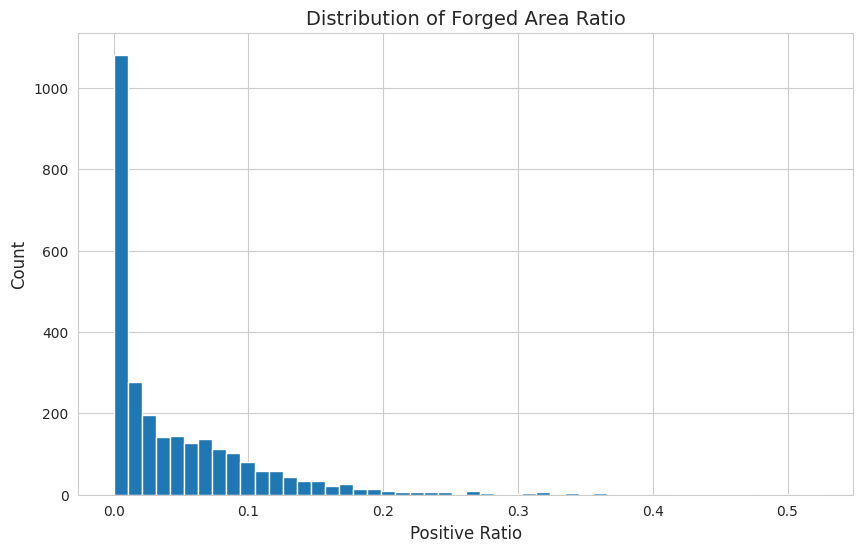

In [105]:
# Histogram: forged area ratio
# ================================
# positive_ratio shows what fraction of each mask is forged.

plt.figure()
plt.hist(mask_content_df["positive_ratio"], bins=50)
plt.title("Distribution of Forged Area Ratio")
plt.xlabel("Positive Ratio")
plt.ylabel("Count")
plt.savefig(FIGURES_DIR / "forged_area_ratio_hist.png", dpi=150, bbox_inches="tight")
plt.show()

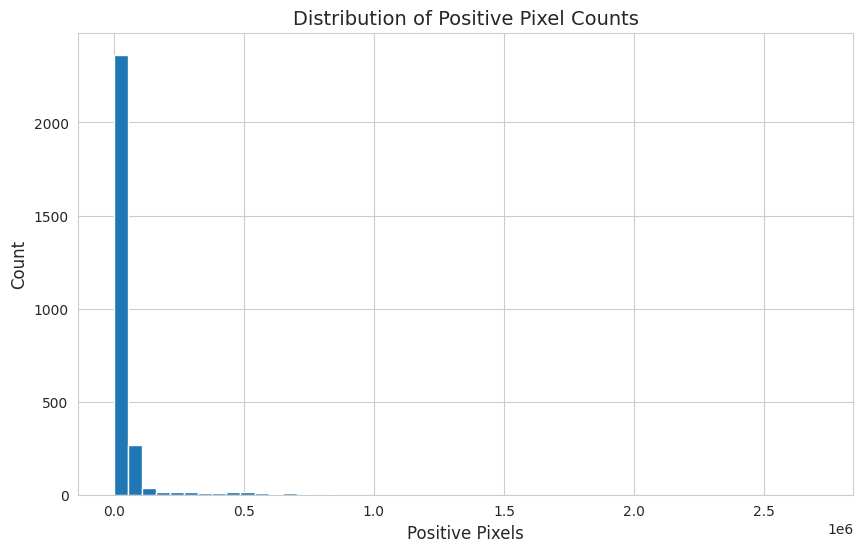

In [106]:
# Histogram: positive pixel count
# ================================
# This gives the absolute size of the forged region.

plt.figure()
plt.hist(mask_content_df["positive_pixels"], bins=50)
plt.title("Distribution of Positive Pixel Counts")
plt.xlabel("Positive Pixels")
plt.ylabel("Count")
plt.savefig(FIGURES_DIR / "positive_pixel_count_hist.png", dpi=150, bbox_inches="tight")
plt.show()

In [107]:
# Mask difficulty / density grouping
# ================================
# IMPORTANT: this is the ONE canonical definition of forgery-density bins
# for the whole project. It matches the paper's stated methodology
# (micro < 0.5%, small 0.5-1%, medium 1-5%, large > 5%) and is the same
# definition used for the stratified split in Section 7 below — earlier
# versions of this notebook used a different threshold (0.1% instead of
# 0.5%) here than the model notebooks used for splitting, which is exactly
# the kind of inconsistency a reviewer will catch. Change it here ONLY,
# and every downstream table and split stays in sync automatically.

def assign_mask_size_group(positive_ratio):
    pct = positive_ratio * 100
    if pct < 0.5:
        return "micro"
    elif pct < 1.0:
        return "small"
    elif pct < 5.0:
        return "medium"
    else:
        return "large"

mask_content_df["mask_size_group"] = mask_content_df["positive_ratio"].apply(assign_mask_size_group)

mask_content_df["mask_size_group"].value_counts()

mask_size_group
large     988
medium    761
micro     640
small     410
Name: count, dtype: int64

In [108]:
# Hardest cases: smallest positive ratios
# ================================
# These are the cases most likely to be lost by bad preprocessing.

hardest_tiny_masks_df = mask_content_df.sort_values(by="positive_ratio", ascending=True).head(20)

hardest_tiny_masks_df[[
    "sample_source", "sample_id", "mask_height", "mask_width",
    "total_pixels", "positive_pixels", "positive_ratio", "mask_size_group"
]]

,sample_source,sample_id,mask_height,mask_width,total_pixels,positive_pixels,positive_ratio,mask_size_group
1667,train,43787,1024,1280,1310720,2,0.000002,micro
1239,train,35234,520,696,361920,2,0.000006,micro
2305,train,57664,520,696,361920,2,0.000006,micro
603,train,2164,520,696,361920,2,0.000006,micro
543,train,20490,520,696,361920,4,0.000011,micro
442,train,1783,520,696,361920,4,0.000011,micro
1846,train,47426,986,1984,1956224,480,0.000245,micro
627,train,22141,1422,2162,3074364,886,0.000288,micro
269,train,14371,1200,1600,1920000,568,0.000296,micro
249,train,13986,1956,1398,2734488,885,0.000324,micro


In [109]:
# Largest forged-area cases
# ================================
# These are easier than micro-forgery cases, but useful for understanding range.

largest_masks_df = mask_content_df.sort_values(by="positive_ratio", ascending=False).head(20)

largest_masks_df[[
    "sample_source", "sample_id", "mask_height", "mask_width",
    "total_pixels", "positive_pixels", "positive_ratio", "mask_size_group"
]]

,sample_source,sample_id,mask_height,mask_width,total_pixels,positive_pixels,positive_ratio,mask_size_group
2273,train,569,125,434,54250,28358,0.522728,large
12,supplemental,20942,545,1814,988630,510150,0.516017,large
236,train,13799,100,742,74200,36764,0.495472,large
776,train,25064,143,938,134134,65122,0.485500,large
2030,train,51464,512,758,388096,181819,0.468490,large
432,train,176,85,517,43945,20424,0.464763,large
1119,train,32575,116,444,51504,23468,0.455654,large
1630,train,42886,158,899,142042,64367,0.453155,large
1815,train,46927,100,742,74200,32778,0.441752,large
463,train,1856,143,528,75504,33056,0.437805,large


In [110]:
# Merge size and mask content metadata
# ================================
# This creates one richer table for later analysis and the canonical split.

paired_metadata_df = paired_size_df.merge(
    mask_content_df[[
        "sample_source", "sample_id", "total_pixels", "num_unique_values",
        "positive_pixels", "positive_ratio", "mask_size_group"
    ]],
    on=["sample_source", "sample_id"],
    how="left"
)

paired_metadata_df.head()

,sample_source,sample_type,sample_id,image_path,mask_path,image_height,image_width,mask_height,mask_width,image_aspect_ratio,mask_aspect_ratio,shapes_match,total_pixels,num_unique_values,positive_pixels,positive_ratio,mask_size_group
0,supplemental,forged,13977,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,1382,1359,1382,1359,0.983357,0.983357,True,1878138,2,48420,0.025781,medium
1,supplemental,forged,14128,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,497,988,497,988,1.987928,1.987928,True,491036,2,44522,0.090670,large
2,supplemental,forged,15257,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,2790,1702,2790,1702,0.610036,0.610036,True,4748580,2,7586,0.001598,micro
3,supplemental,forged,16338,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,4417,2080,4417,2080,0.470908,0.470908,True,9187360,2,327509,0.035648,medium
4,supplemental,forged,16714,/kaggle/input/competitions/recodai-luc-scienti...,/kaggle/input/competitions/recodai-luc-scienti...,1205,2051,1205,2051,1.702075,1.702075,True,2471455,2,344246,0.139289,large


In [111]:
# Save mask content metadata
# ================================
# These outputs will be reused later in preprocessing, training, and Section 7.

mask_content_save_path = METADATA_DIR / "mask_content_audit.csv"
paired_metadata_save_path = METADATA_DIR / "paired_metadata_table.csv"

mask_content_df.to_csv(mask_content_save_path, index=False)
paired_metadata_df.to_csv(paired_metadata_save_path, index=False)

print(f"Saved mask content audit to: {mask_content_save_path}")
print(f"Saved paired metadata table to: {paired_metadata_save_path}")

Saved mask content audit to: /kaggle/working/analysis_outputs/metadata/mask_content_audit.csv
Saved paired metadata table to: /kaggle/working/analysis_outputs/metadata/paired_metadata_table.csv


## Section 6: Visual Inspection of Raw Samples and Masks

Statistics can hide a badly-aligned mask, a mislabeled sample, or a mask encoding the earlier functions
got wrong. Before trusting anything computed above, we look directly at authentic images, forged images
with their masks overlaid, and specifically the hardest micro-forgery cases — the ones most at risk of
being erased entirely by resizing or aggressive augmentation.

In [112]:
# This function loads an image as a NumPy array for display.
# We do not apply preprocessing here because we want to inspect the raw data.

def load_image_for_display(image_path):
    with Image.open(image_path) as img:
        image = img.convert("RGB")
    return np.array(image)

In [113]:
# Reuses the exact same canonical decoder as Sections 4 and 5 — see
# load_binary_mask above — so what you see overlaid here is guaranteed to
# match what the audit tables actually measured, not a fourth reimplementation
# that could drift from the other two.

def load_binary_mask_for_display(mask_path):
    return load_binary_mask(mask_path)

In [114]:
# This is ONLY for visualization.
# Since raw image and mask sizes may differ, we resize the binary mask to image size
# so we can inspect overlay alignment.
#
# Important:
# - use nearest-neighbor interpolation
# - do not use bilinear for masks

def resize_mask_to_image_for_display(binary_mask, image_shape):
    image_h, image_w = image_shape[:2]
    mask_pil = Image.fromarray((binary_mask * 255).astype(np.uint8))
    resized_mask = mask_pil.resize((image_w, image_h), resample=Image.NEAREST)
    resized_mask = (np.array(resized_mask) > 0).astype(np.uint8)
    return resized_mask

In [115]:
# This function helps us visually inspect one sample clearly.

def show_image_mask_overlay(image_path, mask_path=None, title=None):
    image = load_image_for_display(image_path)

    if mask_path is None:
        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.title(title if title else "Authentic Image")
        plt.axis("off")
        plt.show()
        return

    binary_mask = load_binary_mask_for_display(mask_path)
    resized_mask = resize_mask_to_image_for_display(binary_mask, image.shape)

    # Create overlay
    overlay = image.copy()
    overlay[..., 0] = np.where(resized_mask == 1, 255, overlay[..., 0])

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image)
    axes[0].set_title("Raw Image")
    axes[0].axis("off")

    axes[1].imshow(resized_mask, cmap="gray")
    axes[1].set_title("Binary Mask (resized for display)")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    if title:
        fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

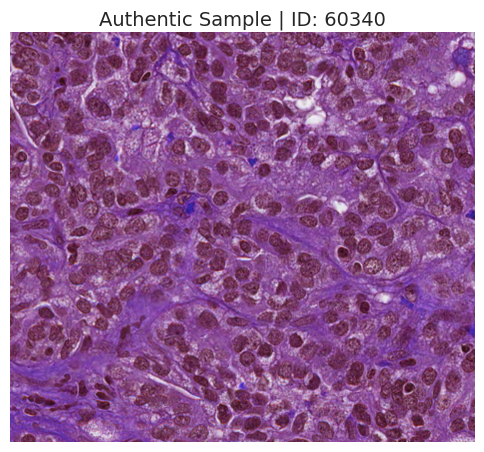

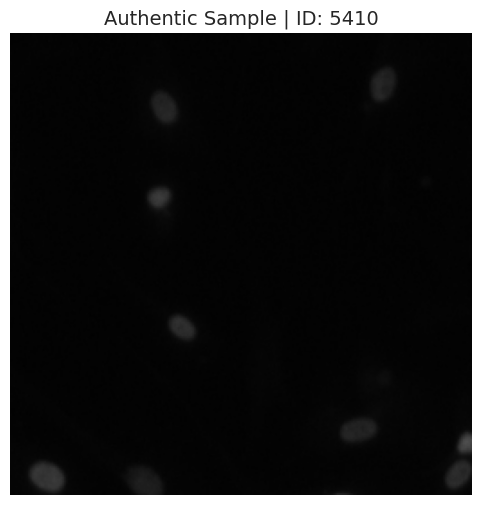

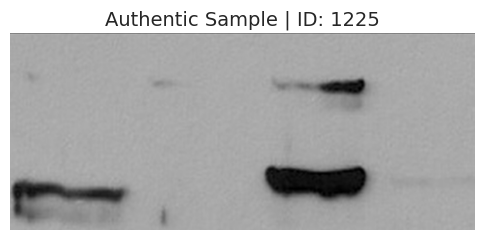

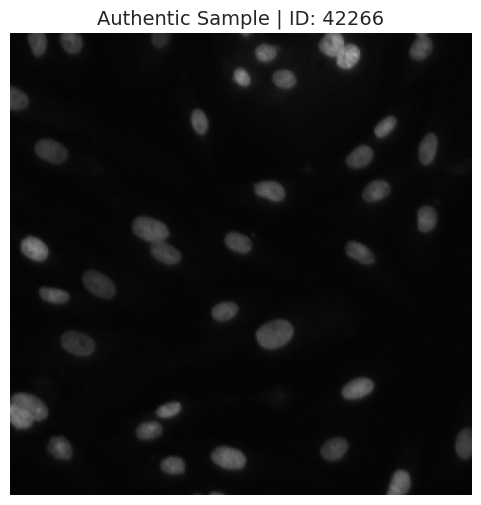

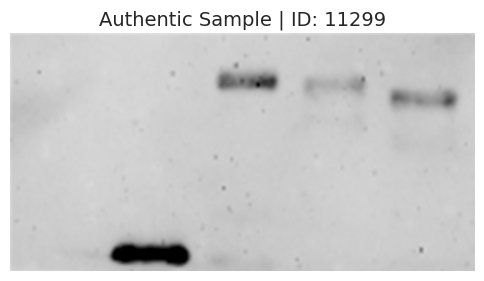

In [116]:
# Visualize authentic samples
# ================================
# Authentic images help us understand what clean scientific images look like.

auth_sample_display = authentic_df.sample(min(5, len(authentic_df)), random_state=SEED)

for _, row in auth_sample_display.iterrows():
    show_image_mask_overlay(
        image_path=row["image_path"],
        mask_path=None,
        title=f"Authentic Sample | ID: {row['sample_id']}"
    )

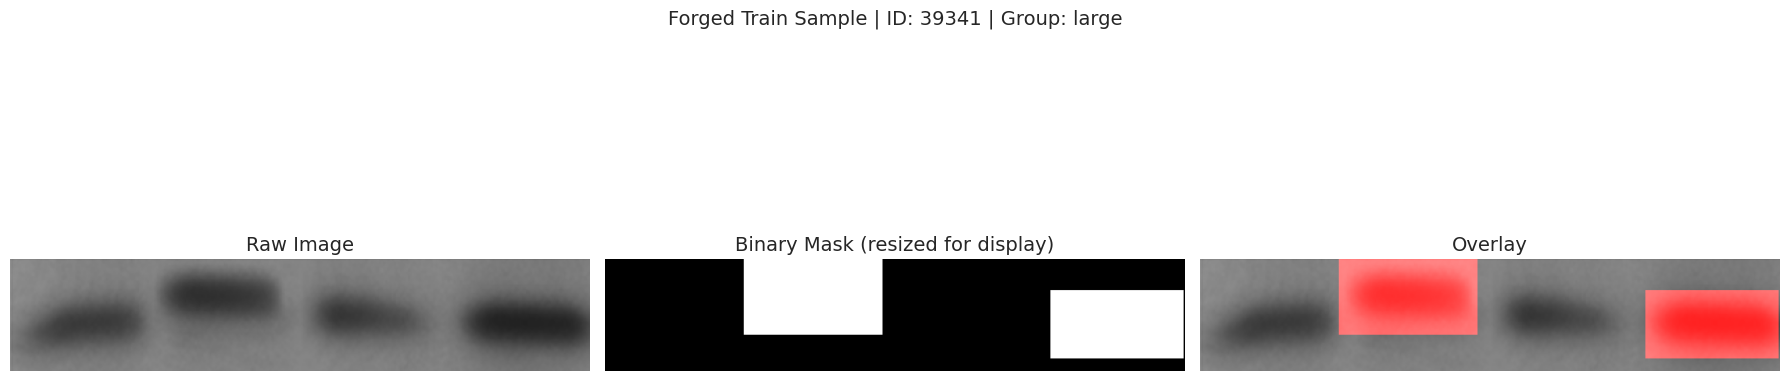

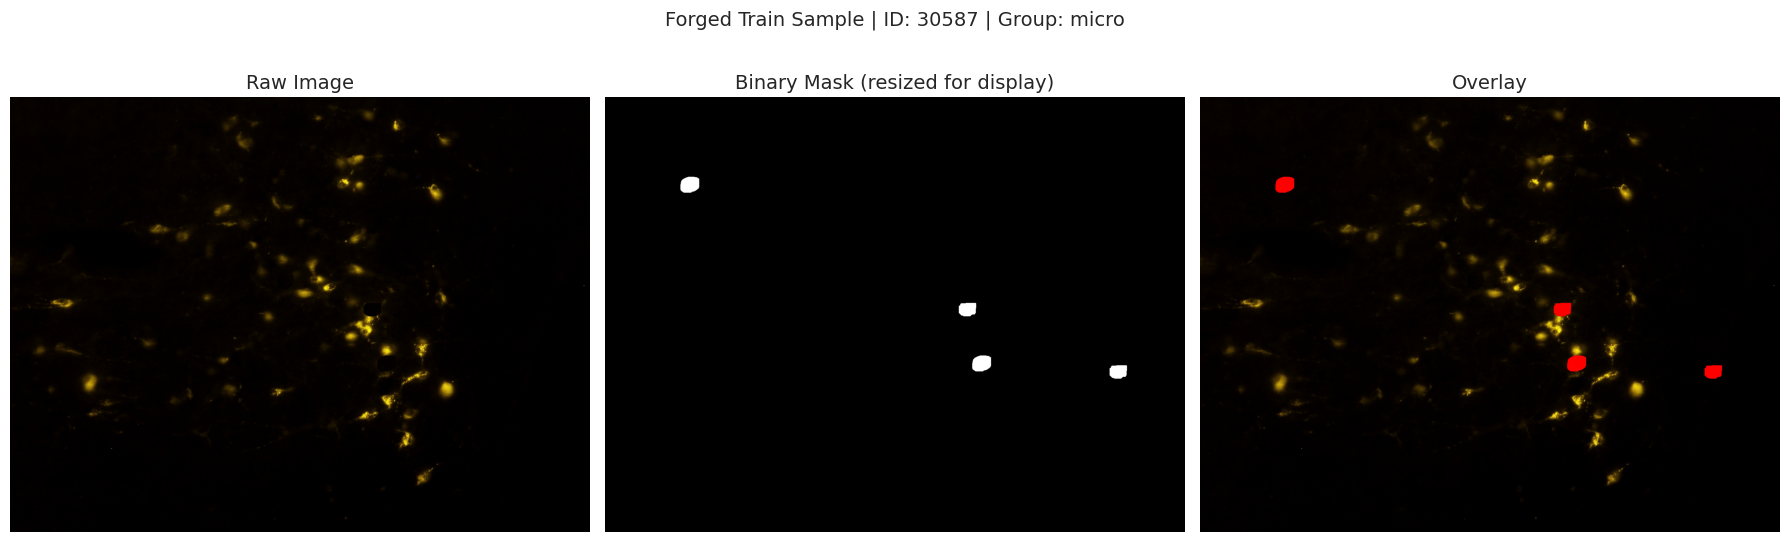

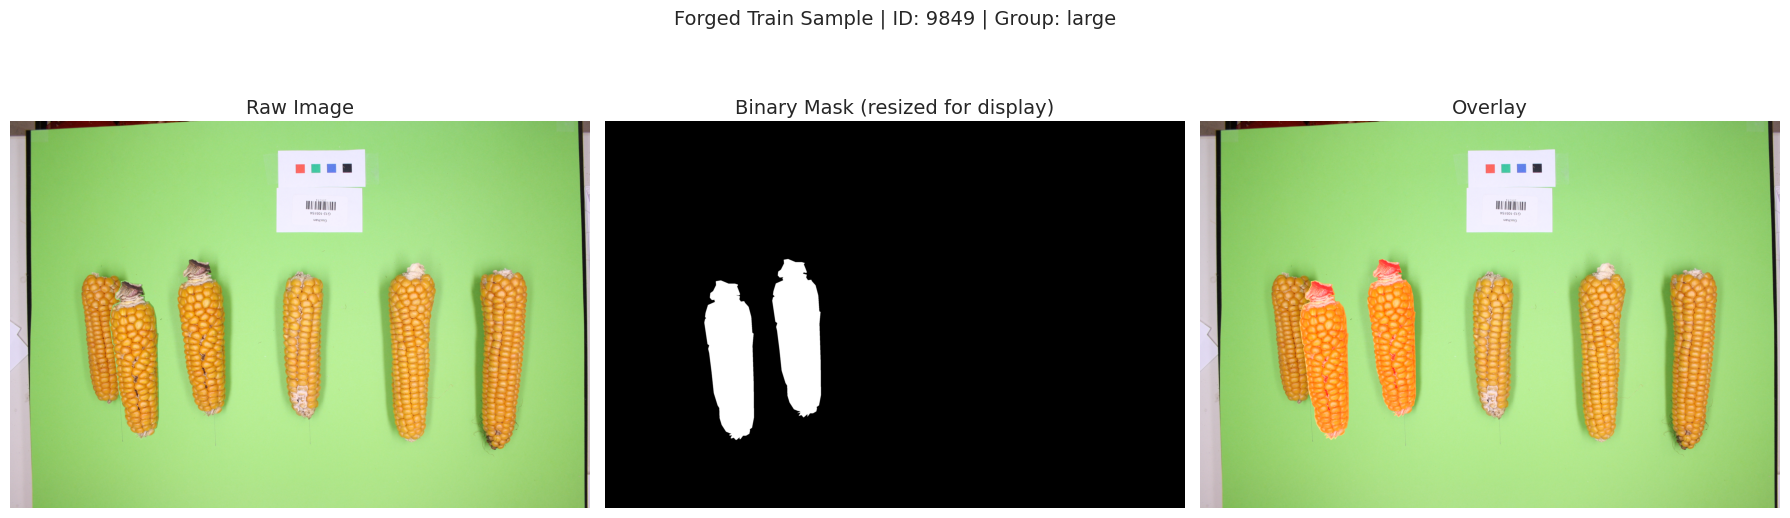

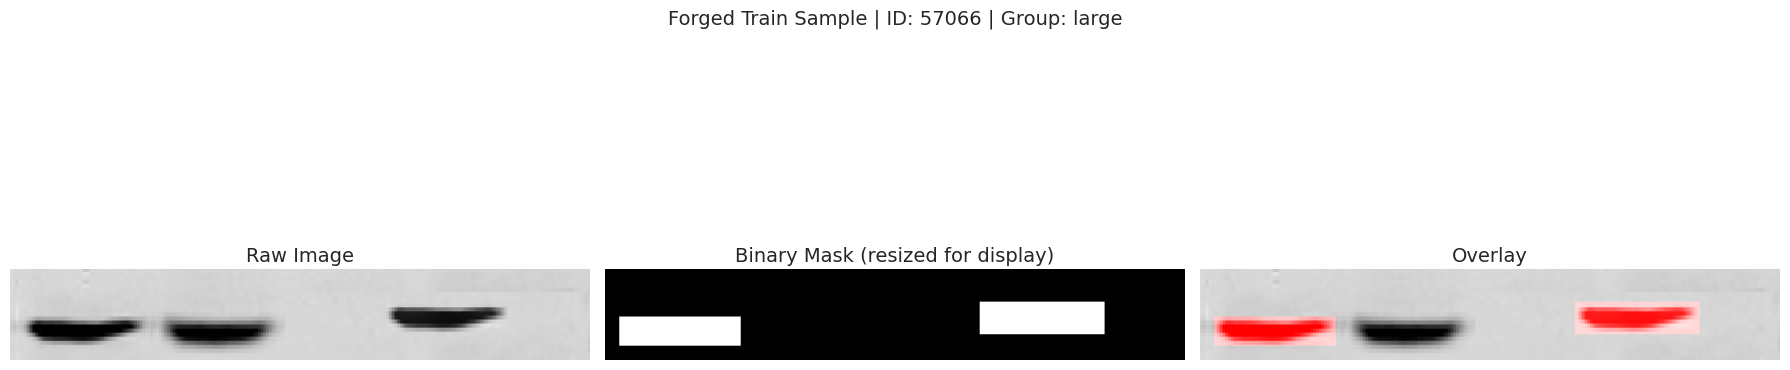

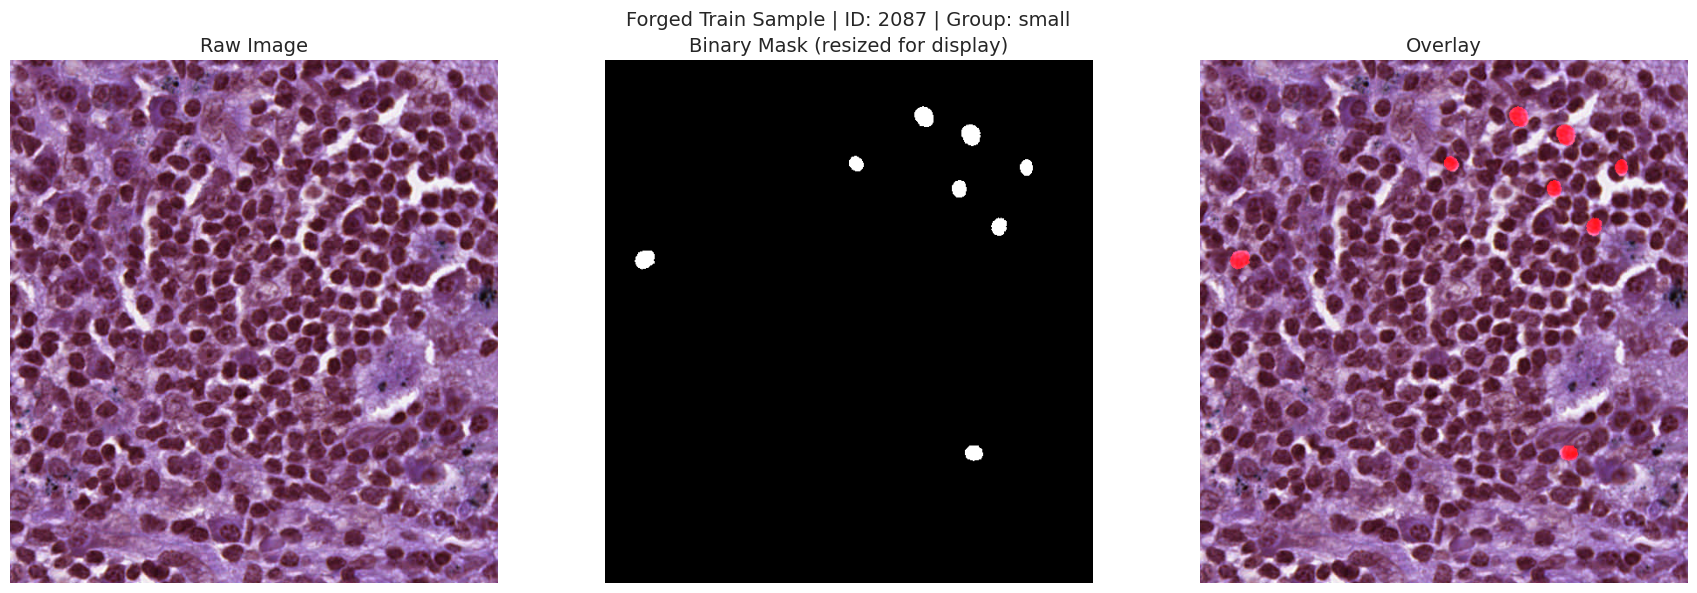

In [117]:
# Visualize random forged training samples
# ================================
# These help us inspect how forged regions appear in the main training set.

forged_train_display = paired_metadata_df[
    paired_metadata_df["sample_source"] == "train"
].sample(5, random_state=SEED)

for _, row in forged_train_display.iterrows():
    show_image_mask_overlay(
        image_path=row["image_path"],
        mask_path=row["mask_path"],
        title=f"Forged Train Sample | ID: {row['sample_id']} | Group: {row['mask_size_group']}"
    )

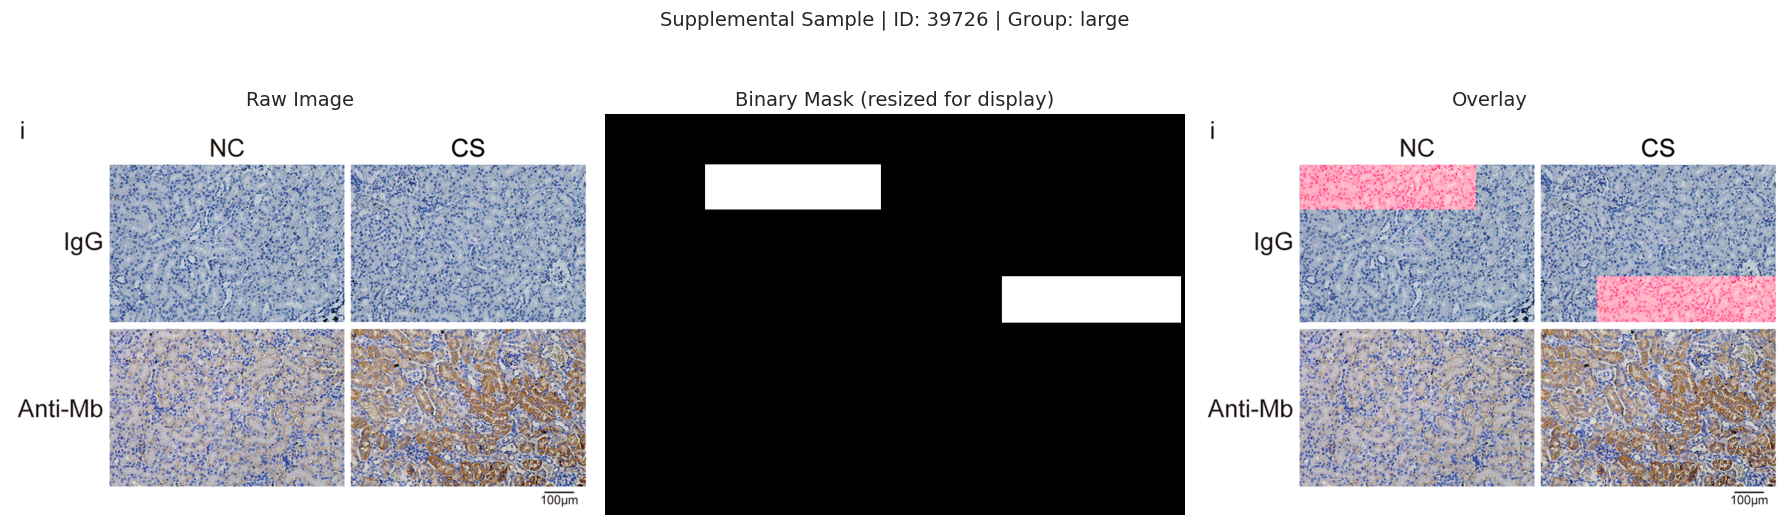

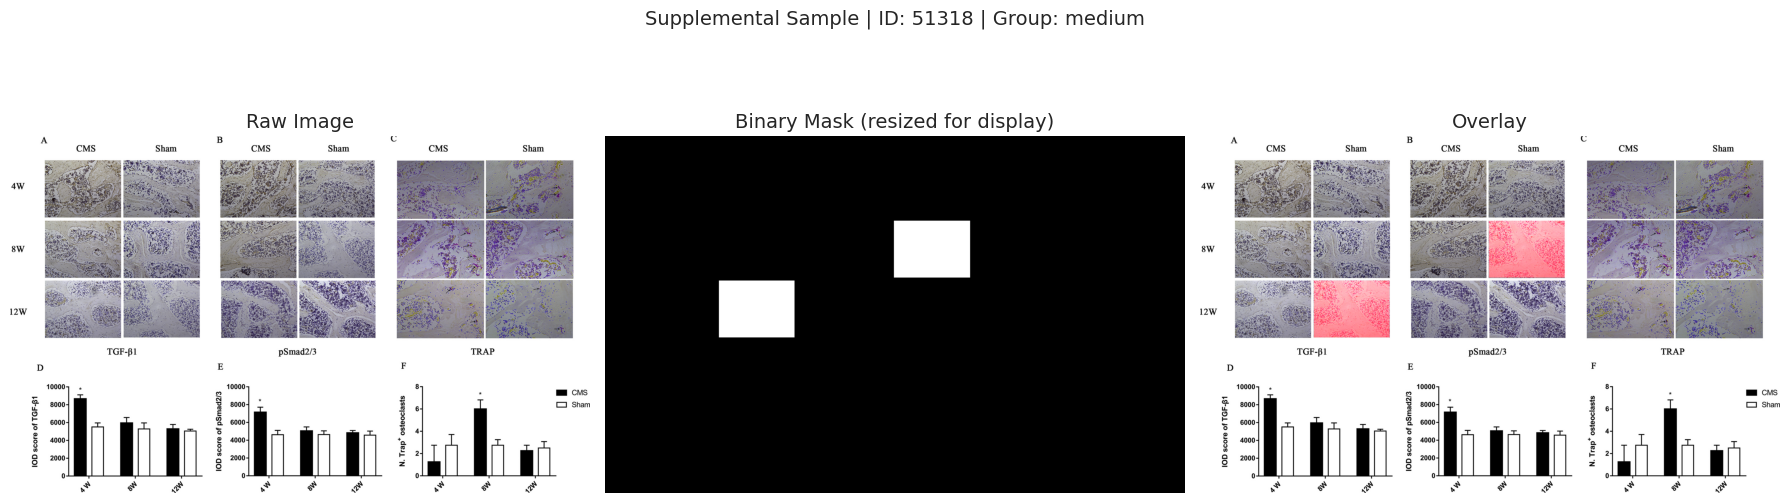

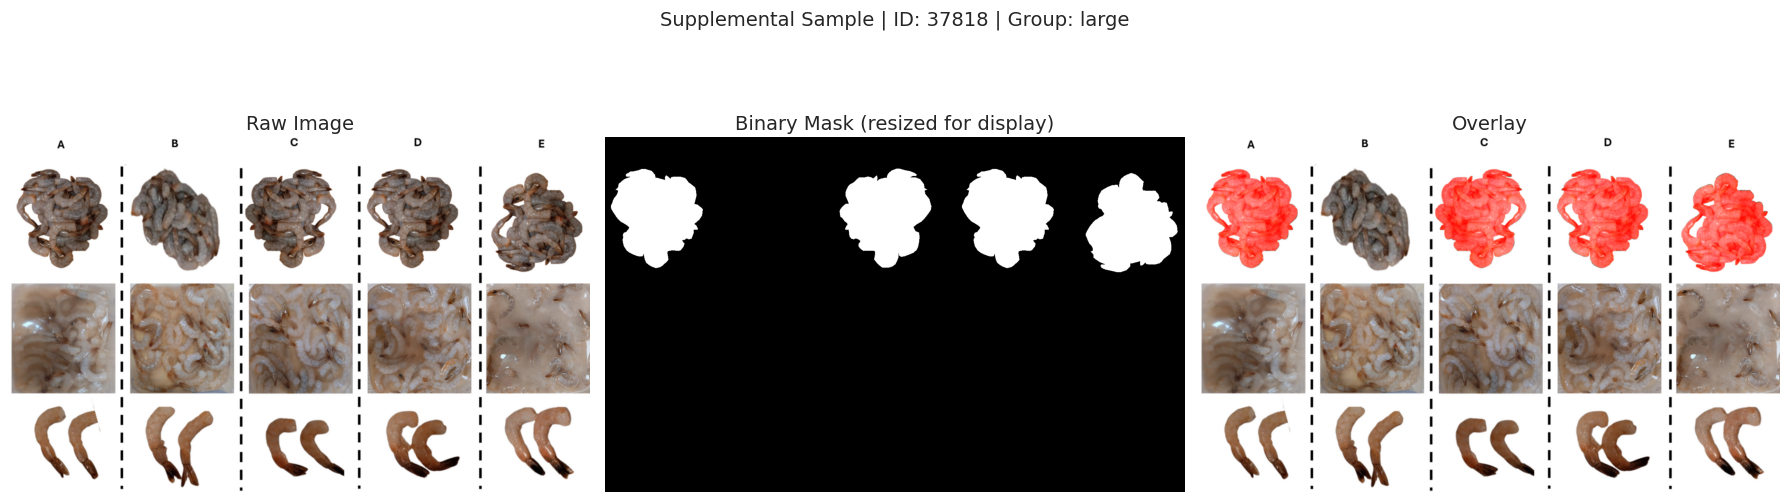

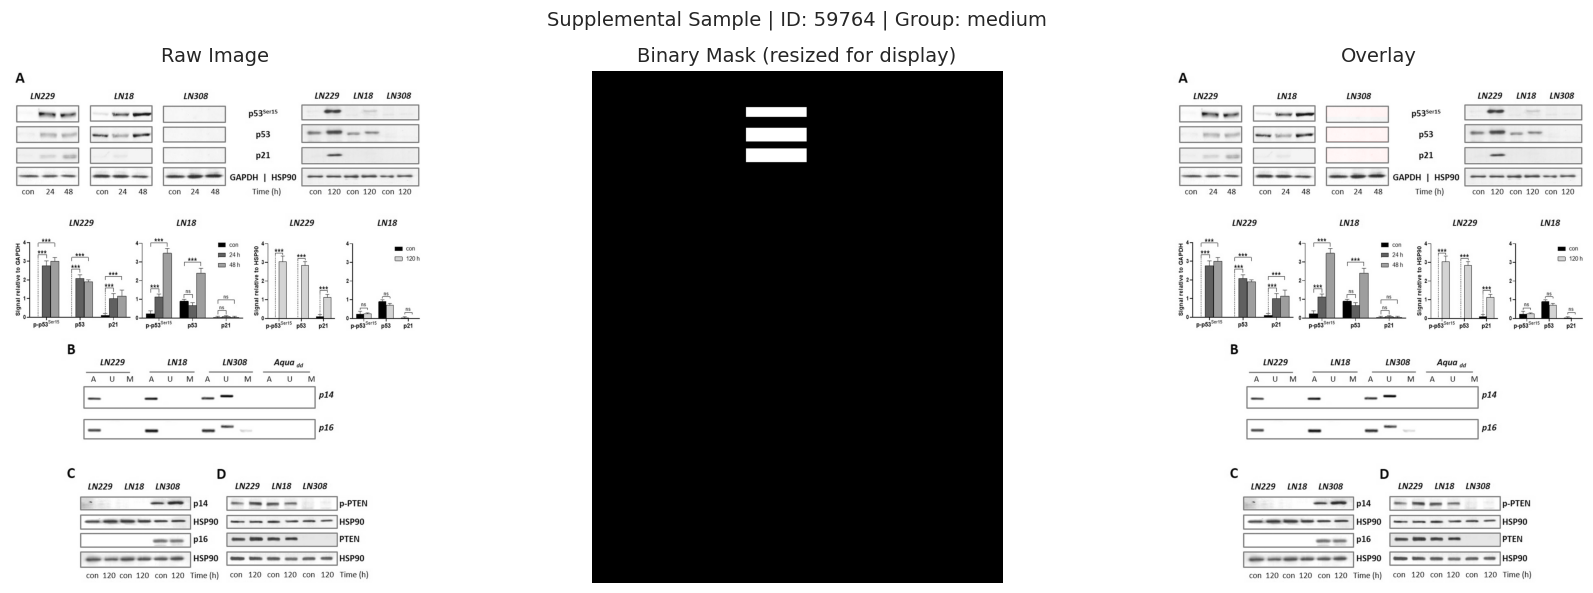

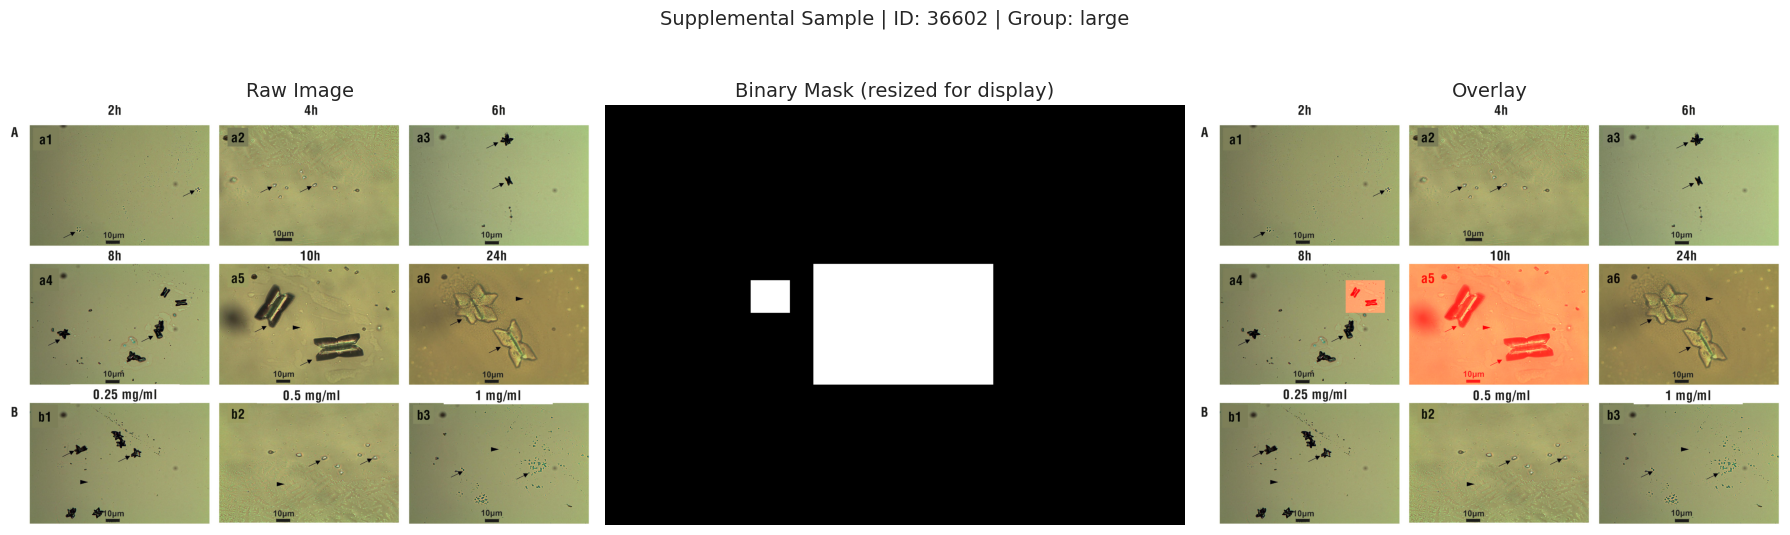

In [118]:
# Visualize random supplemental samples
# ================================
# Supplemental samples may be visually different from the main training images,
# so they deserve separate inspection — if this dataset mirror has any.

supp_rows = paired_metadata_df[paired_metadata_df["sample_source"] == "supplemental"]

if len(supp_rows) > 0:
    supp_display = supp_rows.sample(min(5, len(supp_rows)), random_state=SEED)
    for _, row in supp_display.iterrows():
        show_image_mask_overlay(
            image_path=row["image_path"],
            mask_path=row["mask_path"],
            title=f"Supplemental Sample | ID: {row['sample_id']} | Group: {row['mask_size_group']}"
        )
else:
    print("No supplemental samples found — skipping.")

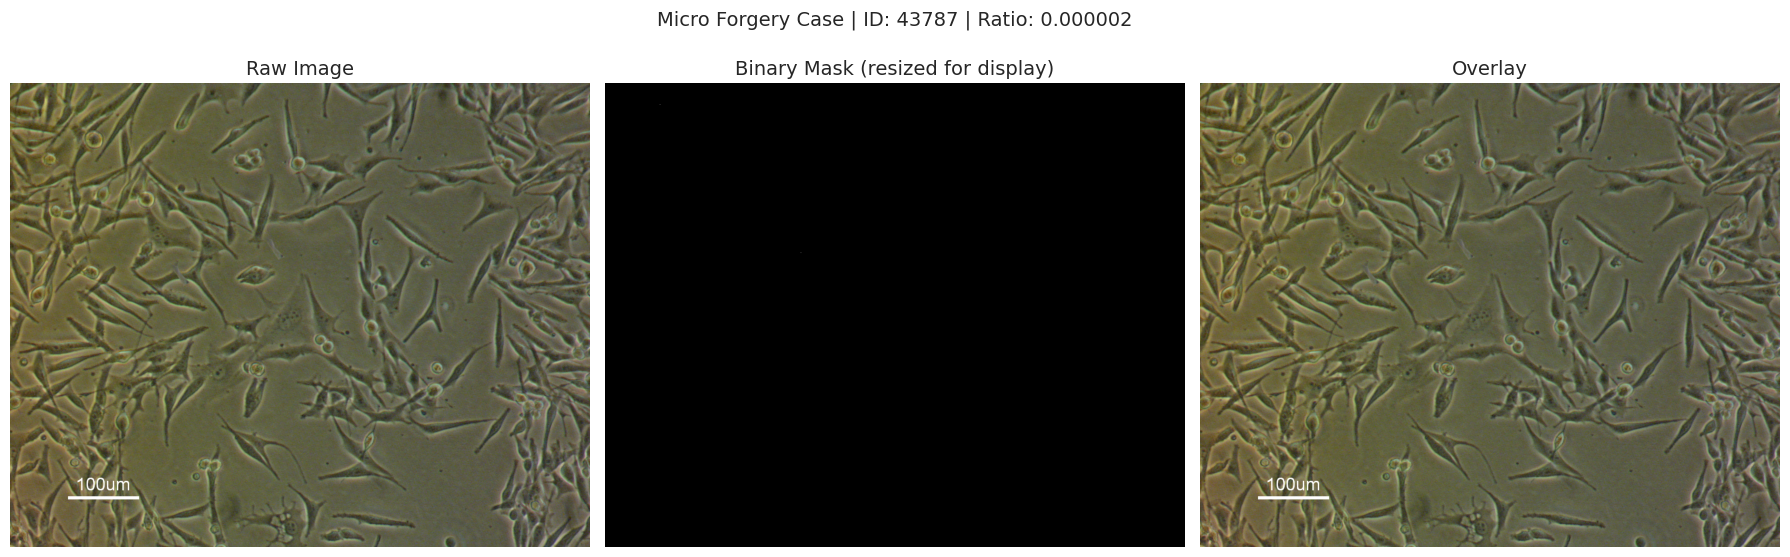

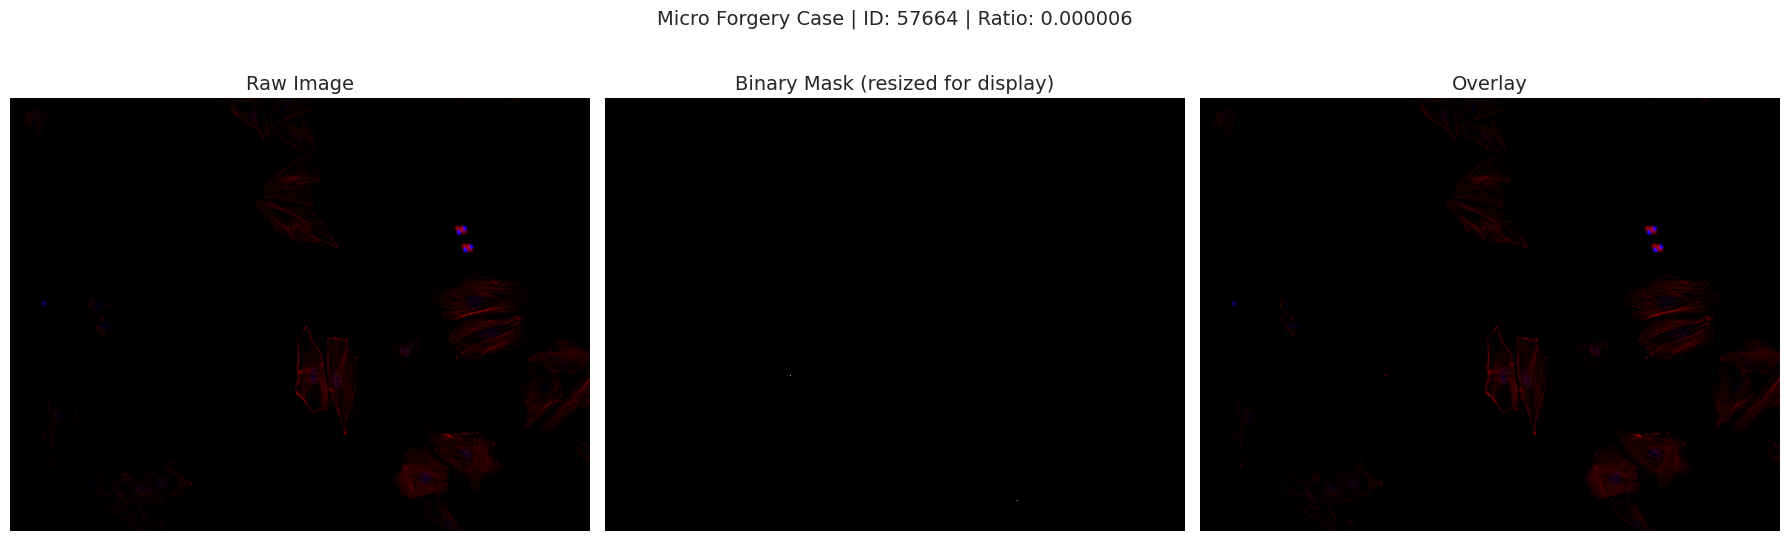

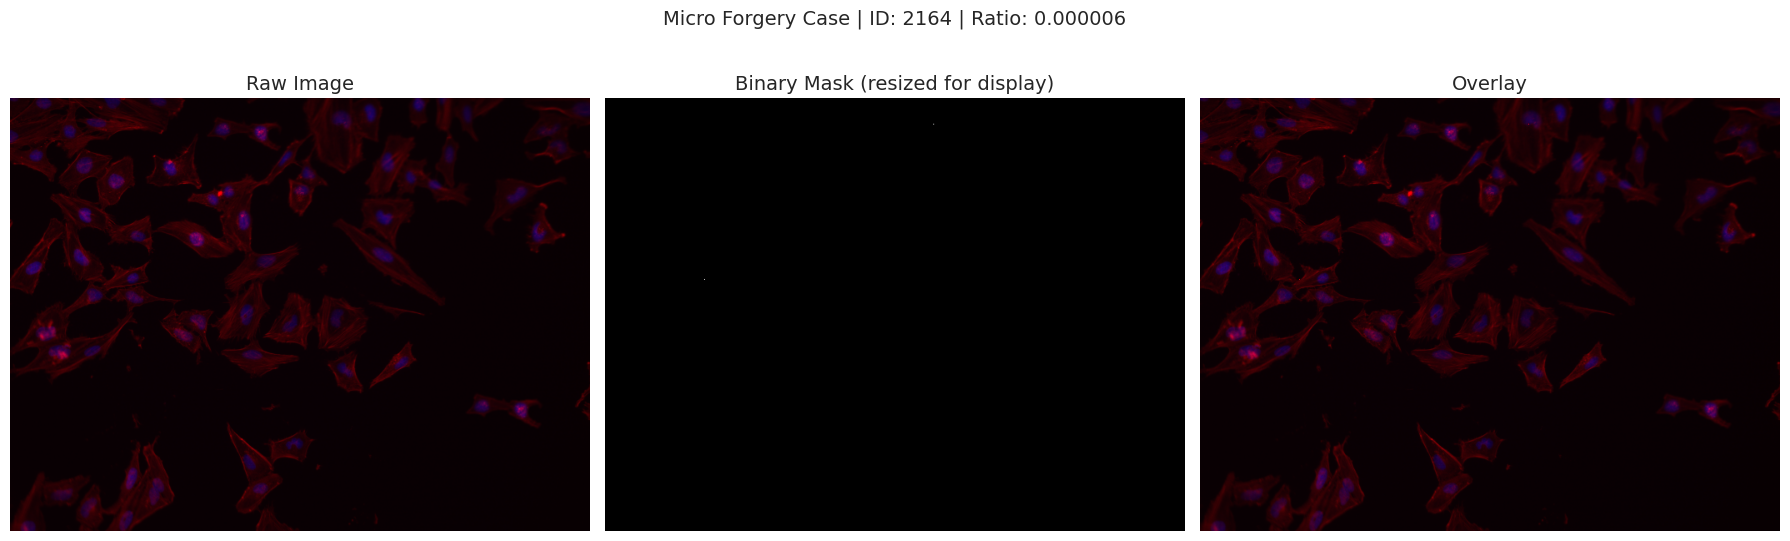

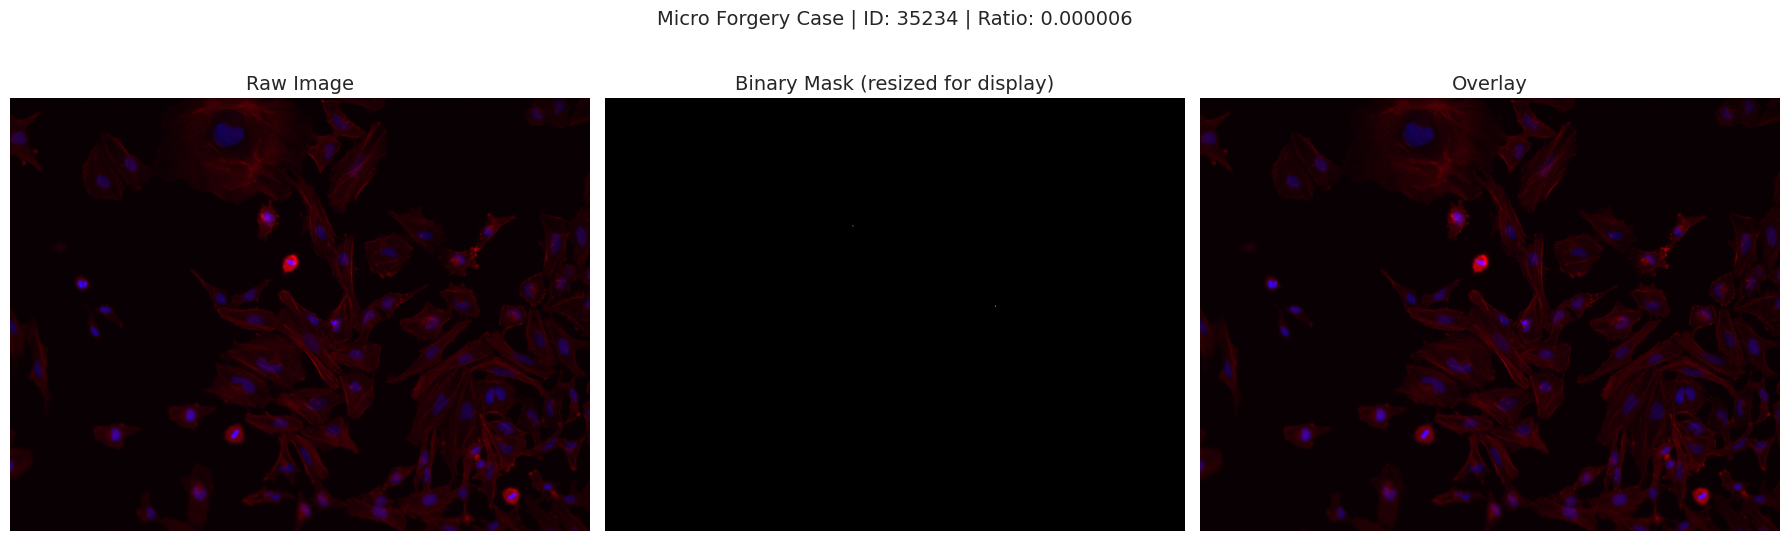

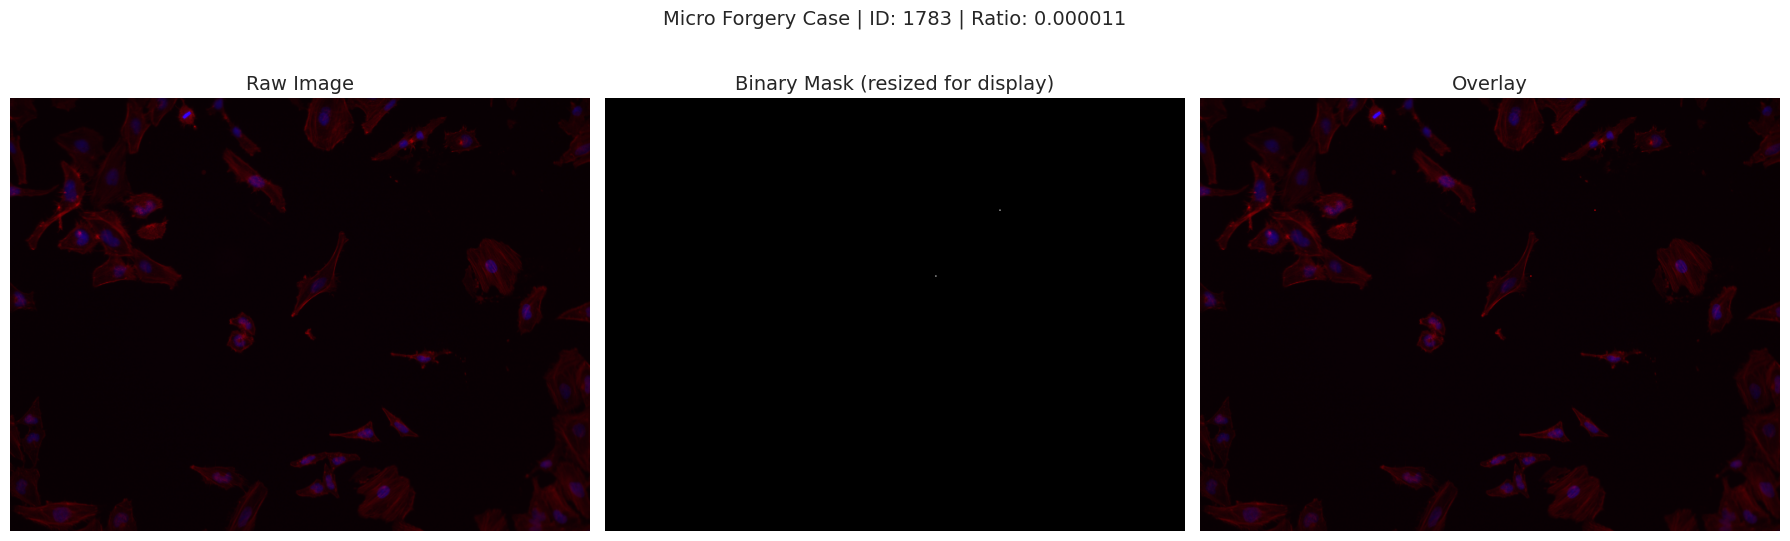

In [119]:
# Visualize hardest micro-forgery cases
# ================================
# These are the most important cases for your project because they are most at risk
# of being lost by bad preprocessing.

micro_display = paired_metadata_df[
    paired_metadata_df["mask_size_group"] == "micro"
].sort_values(by="positive_ratio", ascending=True).head(5)

for _, row in micro_display.iterrows():
    show_image_mask_overlay(
        image_path=row["image_path"],
        mask_path=row["mask_path"],
        title=f"Micro Forgery Case | ID: {row['sample_id']} | Ratio: {row['positive_ratio']:.6f}"
    )

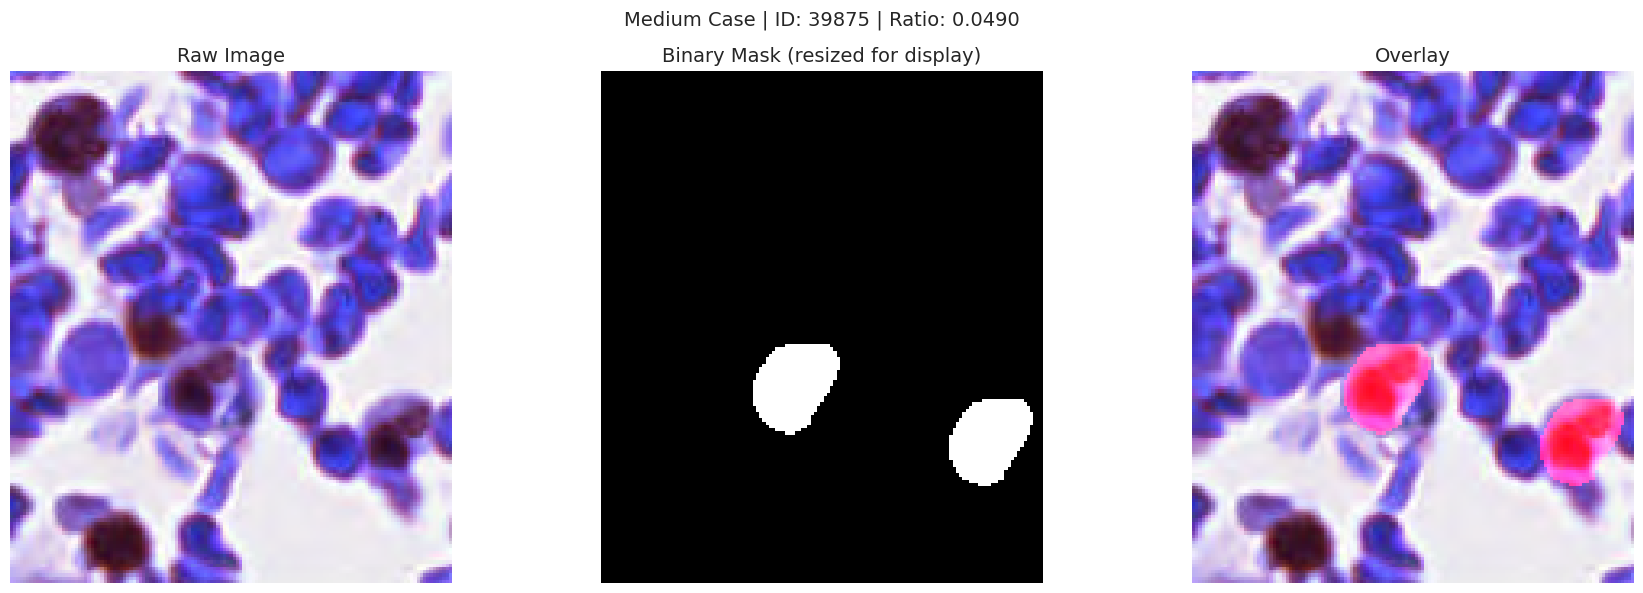

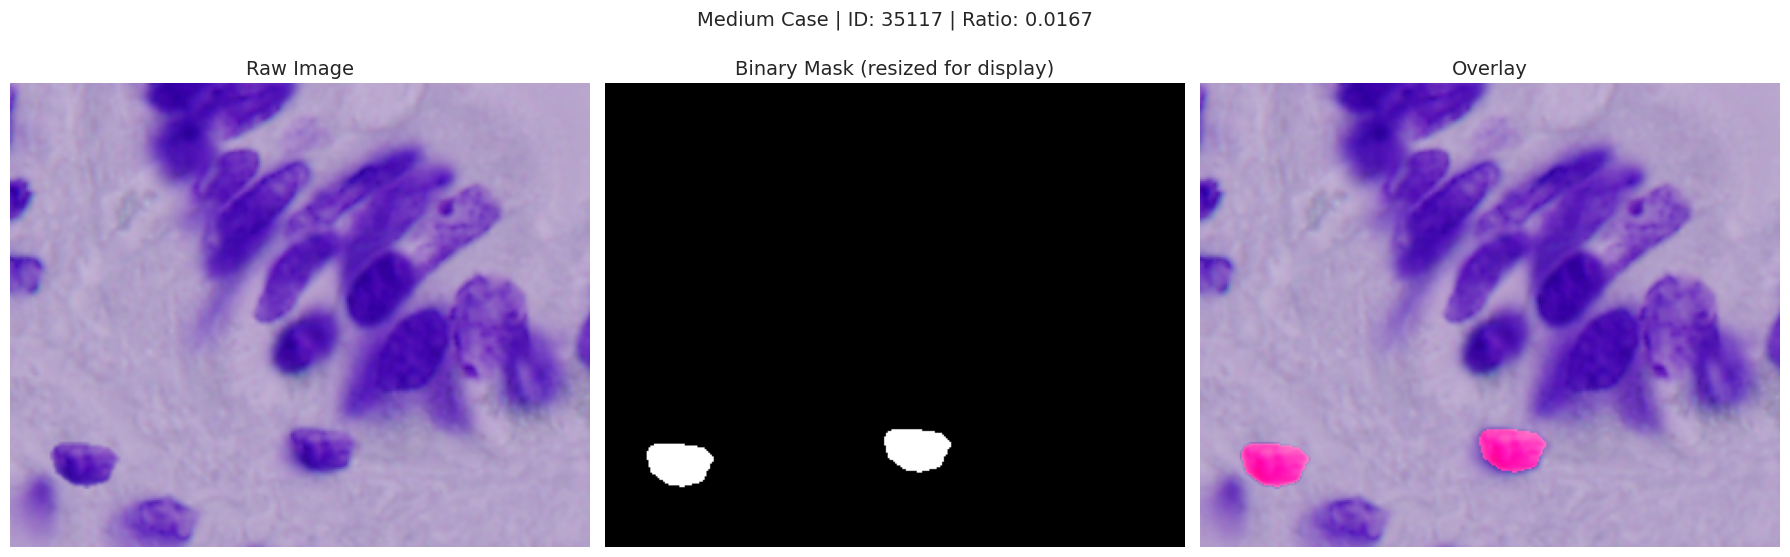

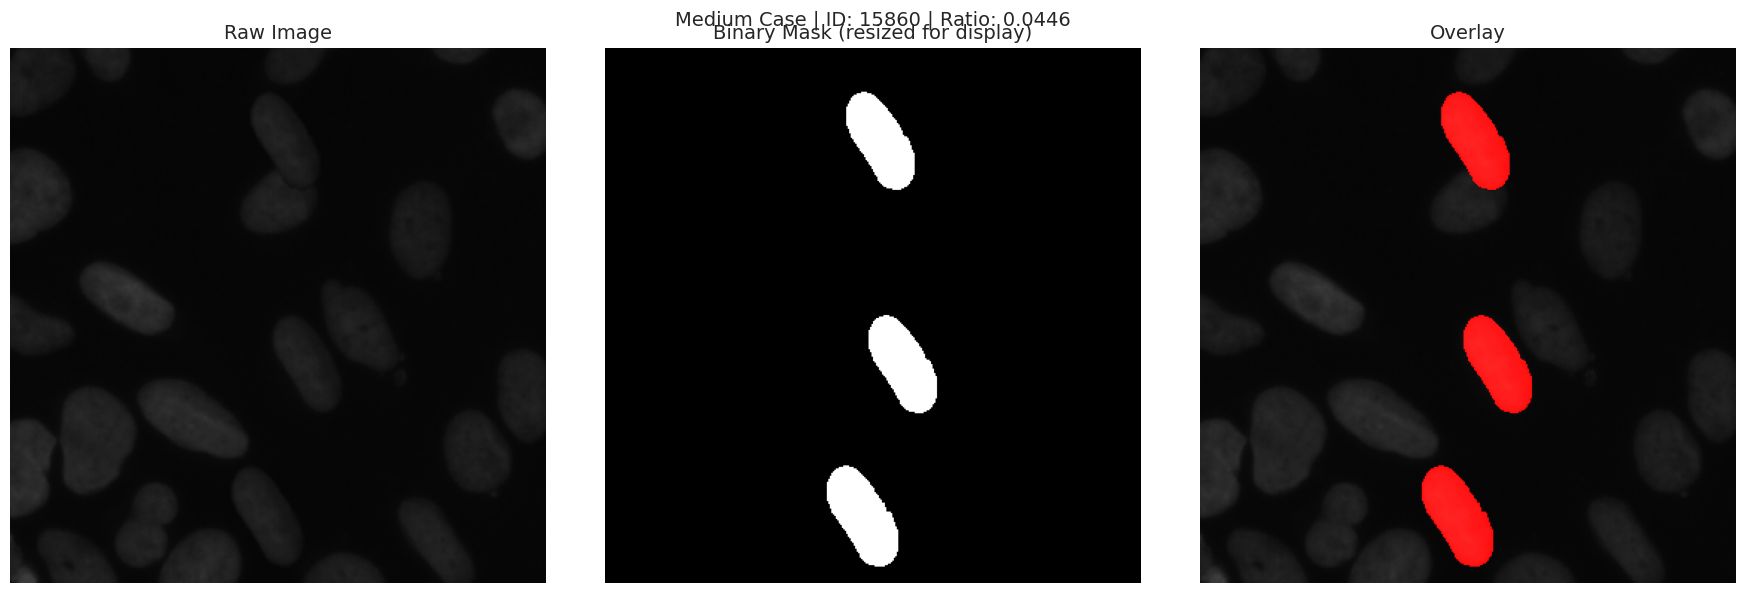

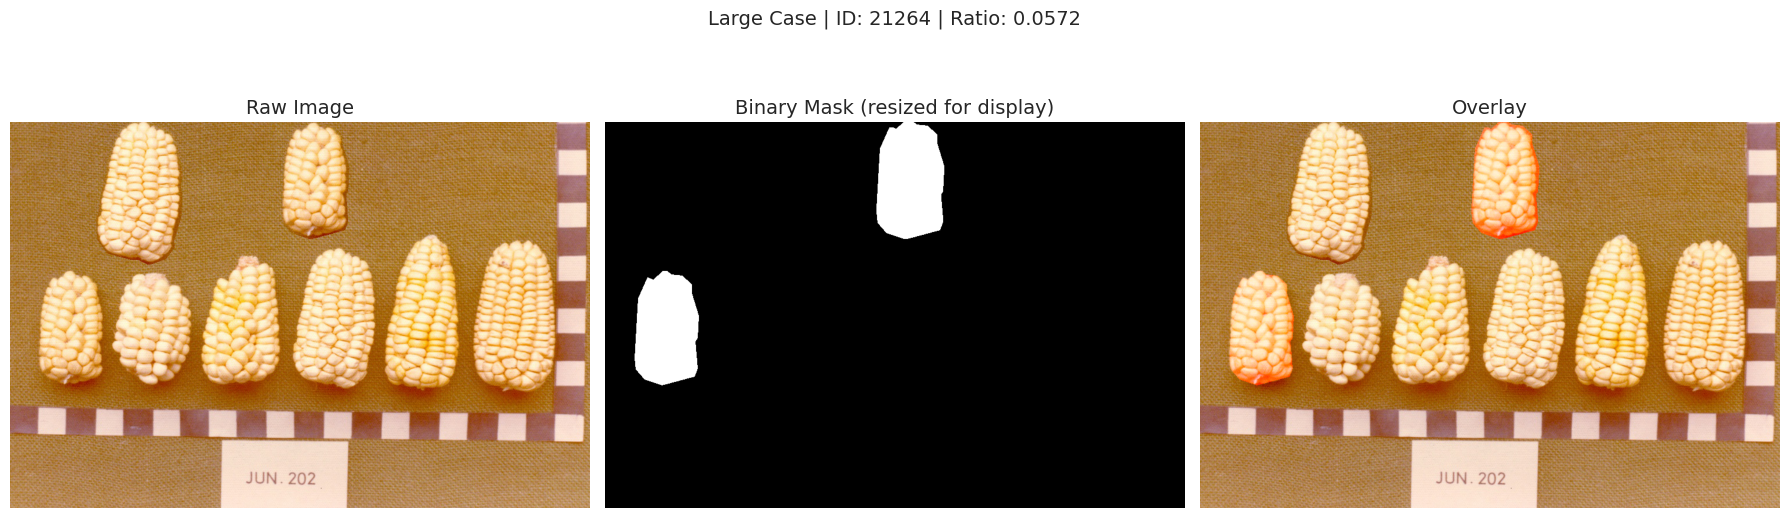

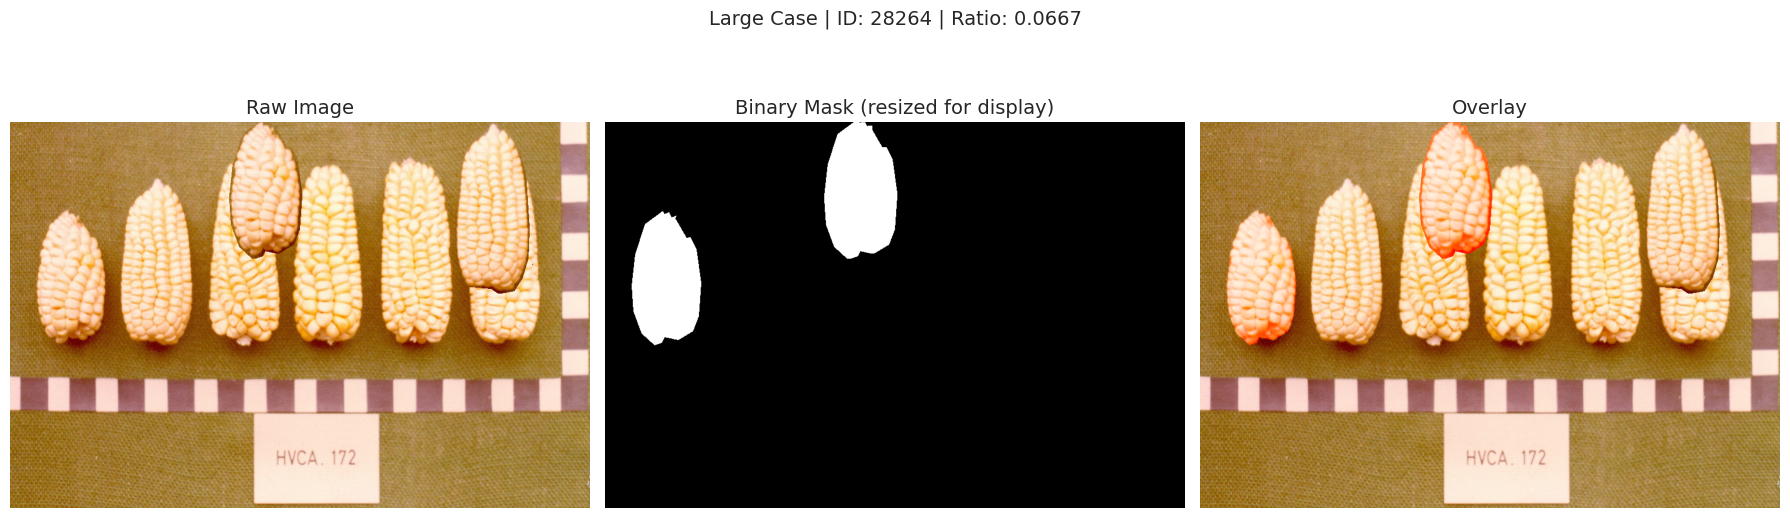

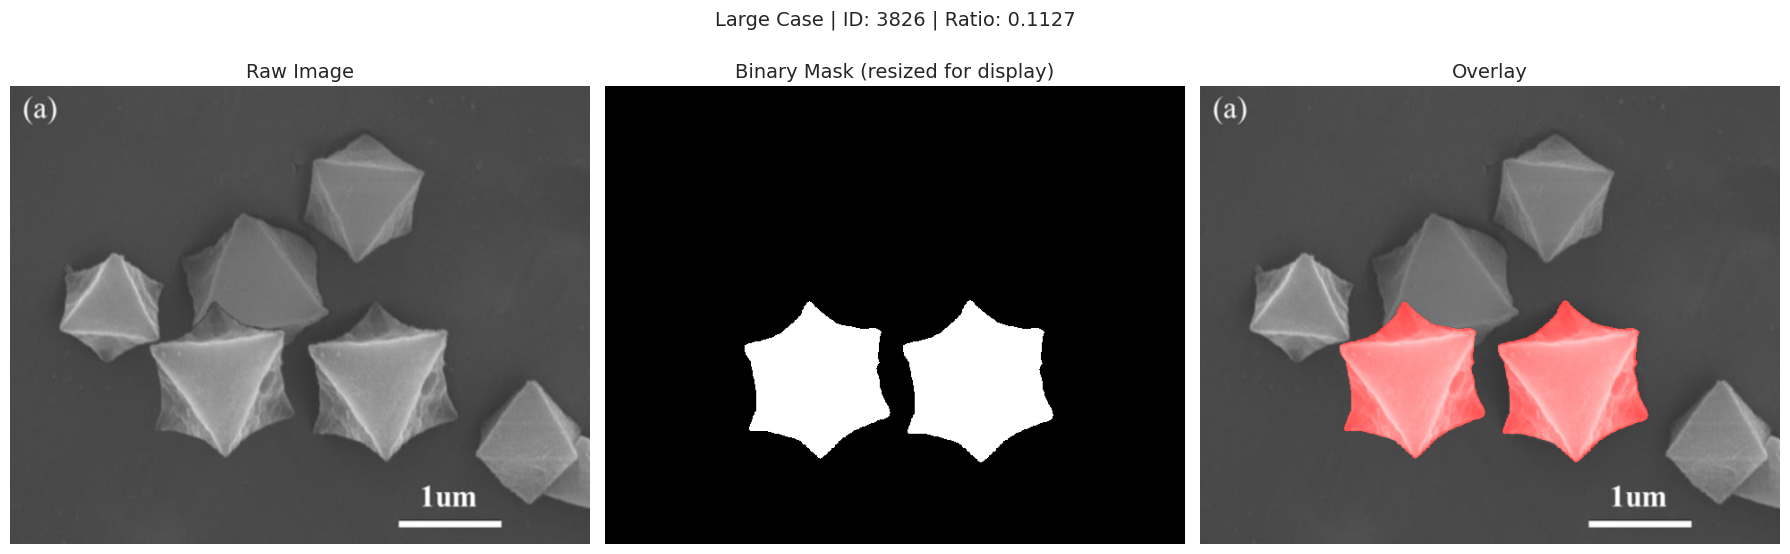

In [120]:
# Visualize medium and large cases
# ================================
# This helps us compare visually easy vs difficult forgery patterns.

comparison_display = pd.concat([
    paired_metadata_df[paired_metadata_df["mask_size_group"] == "medium"].sample(
        min(3, (paired_metadata_df["mask_size_group"] == "medium").sum()), random_state=SEED),
    paired_metadata_df[paired_metadata_df["mask_size_group"] == "large"].sample(
        min(3, (paired_metadata_df["mask_size_group"] == "large").sum()), random_state=SEED)
], ignore_index=True)

for _, row in comparison_display.iterrows():
    show_image_mask_overlay(
        image_path=row["image_path"],
        mask_path=row["mask_path"],
        title=f"{row['mask_size_group'].capitalize()} Case | ID: {row['sample_id']} | Ratio: {row['positive_ratio']:.4f}"
    )

## Section 7: Canonical Train/Val/Test Split

This is the section every other notebook in the project depends on. It is built directly from
`paired_metadata_df` (already sorted, already audited above) rather than a fresh `glob` scan, so the
split is reproducible regardless of filesystem or OS. Only forged (mask-bearing) samples are split —
matching the paper's methodology, authentic images are not used for segmentation training here.

Run this section **once**, save the notebook version, publish `/kaggle/working/analysis_outputs` as a
Kaggle Dataset, and have the baseline, every ablation variant, and every seed re-run load these same
three CSVs. That is what makes the ablation grid and the seed-variance numbers valid comparisons.

In [121]:
# Build the split source table
# ================================
# Only forged (mask-bearing) samples go into the split — authentic images
# play no role in segmentation training here, so including them would just
# dilute the stratification without adding anything the model learns from.
#
# We sort BEFORE splitting for one specific reason: train_test_split splits by
# row position, not by content. If two runs feed it rows in a different order,
# the same random_state produces a DIFFERENT split even though nothing about
# the data changed. Sorting first removes that dependency entirely.
#
# IMPORTANT: sample_id alone (the filename stem) is only unique WITHIN one
# sample_source. "train" and "supplemental" images were indexed independently
# in Section 3, so a filename can coincidentally repeat across the two folders
# without being the same file. unique_id below is what's actually guaranteed
# unique per row — every check and every saved split file uses this, not the
# bare sample_id, to avoid false "leakage" from filename coincidences.

split_source_df = paired_metadata_df.dropna(subset=["mask_path"]).copy()
split_source_df["unique_id"] = split_source_df["sample_source"] + "::" + split_source_df["sample_id"]

duplicate_ids = split_source_df["unique_id"].duplicated().sum()
if duplicate_ids > 0:
    print(f"WARNING: {duplicate_ids} duplicate unique_id rows found — investigate before splitting.")

split_source_df = split_source_df.sort_values("unique_id").reset_index(drop=True)

print(f"Samples available for split: {len(split_source_df)}")
print(split_source_df["mask_size_group"].value_counts())

Samples available for split: 2799
mask_size_group
large     988
medium    761
micro     640
small     410
Name: count, dtype: int64


In [122]:
# Stratified 70/15/15 split by forgery-density bin
# ================================
# A plain random split would let the four-way class imbalance from Section 5
# leak into the split itself — by chance, validation could end up mostly
# "large" (easy) forgeries, making IoU look better than the model really is.
# Stratifying on mask_size_group forces every split to carry the same mix of
# micro/small/medium/large cases as the full dataset.
#
# Two-stage split (70/15/15 overall): first carve off 70% for train, then split
# the remaining 30% evenly into val and test. The SAME SEED drives both stages,
# and it's the SAME SEED used for every model variant and every ablation run
# downstream — that's what guarantees the baseline, the full model, and every
# ablated version are compared on identical data.

train_df, temp_df = train_test_split(
    split_source_df,
    test_size=0.30,
    stratify=split_source_df["mask_size_group"],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["mask_size_group"],
    random_state=SEED
)

split_columns = ["unique_id", "sample_source", "sample_id", "image_path", "mask_path", "mask_size_group", "positive_ratio"]

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    save_path = SPLITS_DIR / f"{name}_split.csv"
    df[split_columns].to_csv(save_path, index=False)
    print(f"\n{name.upper():5s} — {len(df):4d} images  ->  {save_path}")
    print(df["mask_size_group"].value_counts())


TRAIN — 1959 images  ->  /kaggle/working/analysis_outputs/splits/train_split.csv
mask_size_group
large     691
medium    533
micro     448
small     287
Name: count, dtype: int64

VAL   —  420 images  ->  /kaggle/working/analysis_outputs/splits/val_split.csv
mask_size_group
large     148
medium    114
micro      96
small      62
Name: count, dtype: int64

TEST  —  420 images  ->  /kaggle/working/analysis_outputs/splits/test_split.csv
mask_size_group
large     149
medium    114
micro      96
small      61
Name: count, dtype: int64


In [123]:
# Split composition summary
# ================================
# This table is the actual evidence for the split methodology described in
# the paper's Methodology section — instead of describing the stratification
# in prose and hoping it's accurate, this is the real, code-generated
# breakdown of how many micro/small/medium/large cases landed in each split.
# Save the CSV and drop the table straight in; it's traceable back to this
# exact cell if anyone (a reviewer, a marker) asks how it was produced.

split_summary = pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="val"),
    test_df.assign(split="test"),
])

composition_table = pd.crosstab(split_summary["split"], split_summary["mask_size_group"])
composition_table = composition_table.reindex(columns=["micro", "small", "medium", "large"], fill_value=0)
composition_table = composition_table.reindex(["train", "val", "test"])
composition_table["total"] = composition_table.sum(axis=1)

composition_save_path = METADATA_DIR / "split_composition_summary.csv"
composition_table.to_csv(composition_save_path)
print(f"Saved split composition summary to: {composition_save_path}")

composition_table

Saved split composition summary to: /kaggle/working/analysis_outputs/metadata/split_composition_summary.csv


mask_size_group,micro,small,medium,large,total
split,,,,,
train,448,287,533,691,1959
val,96,62,114,148,420
test,96,61,114,149,420


In [124]:
# Leakage sanity check
# ================================
# A single sample appearing in two splits is a silent, severe bug — the
# model would effectively be "tested" on data it already saw in training,
# inflating every metric downstream without any obvious symptom.
#
# We check on unique_id (sample_source + sample_id), NOT bare sample_id.
# Bare sample_id is only unique within one source folder, so two different
# files from "train" and "supplemental" can legitimately share a filename
# stem — checking on sample_id alone would flag that coincidence as
# leakage even though train_test_split never actually duplicated a row.

train_ids = set(train_df["unique_id"])
val_ids   = set(val_df["unique_id"])
test_ids  = set(test_df["unique_id"])

print("train & val overlap  :", len(train_ids & val_ids))
print("train & test overlap :", len(train_ids & test_ids))
print("val & test overlap   :", len(val_ids & test_ids))

assert not (train_ids & val_ids), "Leakage between train and val!"
assert not (train_ids & test_ids), "Leakage between train and test!"
assert not (val_ids & test_ids), "Leakage between val and test!"

print("\nNo overlap — splits are clean.")

train & val overlap  : 0
train & test overlap : 0
val & test overlap   : 0

No overlap — splits are clean.
